In [ ]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import time
from sklearn.linear_model import Ridge
from sklearn.preprocessing import StandardScaler

In [2]:
cx = pd.read_csv("./data/outputs/symptoms_weekly_user.csv")
llm = pd.read_csv("./data/llm_weekly_user.csv")

print("cx:", cx.shape)
print("llm:", llm.shape)

cx: (16467, 34)
llm: (16336, 9)


In [3]:
cx.head(5)

,user_id,week,valence_w,arousal_w,radius_w,n_posts,anx_score,dep_score,ptsd_score,mania_score,...,empath_health_mean_z,empath_contentment_mean_z,empath_fear_mean_z,empath_trust_mean_z,empath_hate_mean_z,empath_therapy_mean_z,empath_sleep_mean_z,empath_anger_mean_z,empath_shame_mean_z,empath_optimism_mean_z
0,1001,2025-07-14,-0.673745,0.454293,0.826966,3,0.695444,0.315764,0.835437,0.259443,...,0.707331,0.527432,2.035154,-0.767102,0.685984,1.151567,0.087742,-0.441444,0.324786,0.612550
1,1002,2025-07-07,1.621301,-2.060086,2.621559,1,0.200000,0.241136,0.200000,0.241136,...,-0.856687,-0.727392,-0.731852,3.171496,-0.679259,-0.706984,-0.417312,-0.441444,-0.862163,-0.858679
2,1002,2025-07-14,0.746765,-0.075573,1.175629,2,0.200000,0.259128,0.228586,0.287919,...,-0.064543,0.244382,-0.510700,0.205964,-0.679259,0.131225,-0.417312,-0.441444,-0.027287,0.502107
3,1003,2025-07-14,-0.980784,0.515790,1.108141,1,0.403032,0.385207,0.391219,0.291834,...,-0.295585,0.730268,0.834639,-0.767102,1.084869,-0.706984,-0.417312,-0.441444,2.268624,0.575207
4,1004,2023-10-16,-0.085450,0.800728,0.995097,3,0.481419,0.241136,0.350870,0.366142,...,-0.423351,0.166135,-0.284283,-0.130561,-0.511247,-0.230628,-0.417312,-0.178049,0.553874,0.352986


In [4]:
cx.columns

Index(['user_id', 'week', 'valence_w', 'arousal_w', 'radius_w', 'n_posts',
       'anx_score', 'dep_score', 'ptsd_score', 'mania_score', 'sui_score',
       'anx_label', 'dep_label', 'ptsd_label', 'mania_label', 'sui_label',
       'empath_anxiety_mean_z', 'empath_pain_mean_z', 'empath_violence_mean_z',
       'empath_sadness_mean_z', 'empath_depression_mean_z',
       'empath_help_mean_z', 'empath_love_mean_z', 'empath_suffering_mean_z',
       'empath_health_mean_z', 'empath_contentment_mean_z',
       'empath_fear_mean_z', 'empath_trust_mean_z', 'empath_hate_mean_z',
       'empath_therapy_mean_z', 'empath_sleep_mean_z', 'empath_anger_mean_z',
       'empath_shame_mean_z', 'empath_optimism_mean_z'],
      dtype='object')

In [5]:
llm.head()

,user_id,week,v_hat_mean,a_hat_mean,r_hat_mean,v_true_mean,a_true_mean,r_true_mean,posts
0,1001,2025-07-14,-0.409809,0.125939,0.481530,-0.615691,0.307426,0.717833,3
1,1002,2025-07-07,0.524243,-2.438016,2.493743,1.198129,-1.814492,2.174372,1
2,1002,2025-07-14,0.015013,0.162249,0.248241,0.807889,0.134938,1.144961,2
3,1003,2025-07-14,-0.508256,0.219530,0.553641,-0.938942,0.285763,0.981464,1
4,1004,2023-10-16,0.201641,0.360576,0.859492,0.139780,0.864974,1.067681,3


In [6]:
keys = ["user_id", "week"]

left = cx.reset_index().merge(
    llm[keys].drop_duplicates(),
    on=keys,
    how="left",
    indicator=True
)

missing = left[left["_merge"] == "left_only"].drop(columns=["_merge"])

print(f"Rows in cx but not in llm: {len(missing)}")
print("Original cx indices for missing rows:", missing["index"].tolist()[:20])
missing.head(20)

Rows in cx but not in llm: 131
Original cx indices for missing rows: [882, 1931, 1975, 2095, 2227, 2699, 3718, 3950, 3972, 4062, 4297, 4298, 4299, 4300, 4303, 4304, 4305, 4306, 4516, 4548]


,index,user_id,week,valence_w,arousal_w,radius_w,n_posts,anx_score,dep_score,ptsd_score,...,empath_health_mean_z,empath_contentment_mean_z,empath_fear_mean_z,empath_trust_mean_z,empath_hate_mean_z,empath_therapy_mean_z,empath_sleep_mean_z,empath_anger_mean_z,empath_shame_mean_z,empath_optimism_mean_z
882,882,1035,2020-10-26,1.223488,1.514760,1.947157,1,0.200000,0.241136,0.200000,...,-0.856687,-0.727392,-0.731852,-0.767102,-0.679259,-0.706984,-0.417312,-0.441444,-0.862163,-0.858679
1931,1931,1051,2025-06-09,1.223488,1.514760,1.947157,1,0.200000,0.241136,0.200000,...,-0.856687,-0.727392,-0.731852,-0.767102,-0.679259,-0.706984,-0.417312,-0.441444,-0.862163,-0.858679
1975,1975,1062,2022-07-11,4.138606,-0.600160,4.181895,1,0.200000,0.241136,0.200000,...,-0.856687,-0.727392,-0.731852,-0.767102,-0.679259,-0.706984,-0.417312,-0.441444,-0.862163,7.744636
2095,2095,1077,2025-05-19,1.223488,1.514760,1.947157,1,0.200000,0.241136,0.200000,...,-0.856687,-0.727392,-0.731852,-0.767102,-0.679259,-0.706984,-0.417312,-0.441444,-0.862163,-0.858679
2227,2227,1082,2021-01-11,1.223488,1.514760,1.947157,1,0.200000,0.241136,0.200000,...,-0.856687,-0.727392,-0.731852,-0.767102,-0.679259,-0.706984,-0.417312,-0.441444,-0.862163,-0.858679
2699,2699,1116,2020-12-07,1.223488,1.514760,1.947157,1,0.200000,0.241136,0.200000,...,-0.856687,-0.727392,-0.731852,-0.767102,-0.679259,-0.706984,-0.417312,-0.441444,-0.862163,-0.858679
3718,3718,1165,2022-10-31,3.023427,-1.689186,3.463301,1,0.200000,0.241136,0.200000,...,-0.856687,-0.727392,-0.731852,13.017989,-0.679259,-0.706984,-0.417312,-0.441444,-0.862163,-0.858679
3950,3950,1226,2025-03-03,-0.294721,-0.518088,0.596050,1,0.200022,0.552600,0.400089,...,-0.856687,-0.727392,-0.731852,-0.767102,13.433767,-0.706984,22.815179,-0.441444,-0.862163,10.612408
3972,3972,1234,2024-05-27,1.223488,1.514760,1.947157,1,0.200000,0.241136,0.200000,...,-0.856687,-0.727392,-0.731852,-0.767102,-0.679259,-0.706984,-0.417312,-0.441444,-0.862163,-0.858679
4062,4062,1251,2025-02-03,-2.037270,3.329804,3.903596,1,0.400000,0.241136,0.200000,...,-0.856687,-0.727392,-0.731852,-0.767102,-0.679259,-0.706984,-0.417312,-0.441444,-0.862163,-0.858679


The reason we lost 131 rows of data from llm(llm_weekly_user) is because we filtered token>5 from Mental RoBERTa pipeline.

In [7]:
cx = cx.rename(columns={
    "valence_z_mean": "v_true_mean",
    "arousal_z_mean": "a_true_mean",
    "radius_z_mean": "r_true_mean",
    "n_posts": "posts_true"
})

cx["week"] = pd.to_datetime(cx["week"])
llm["week"] = pd.to_datetime(llm["week"])

In [8]:
merged = pd.merge(cx, llm, on=["user_id", "week"], how="inner").sort_values(by=["user_id", "week"]).reset_index(drop=True)

if "posts" in merged.columns and "posts_true" in merged.columns:
    merged = merged.drop(columns=["posts"])
    
base_columns = ["v_true_mean", "a_true_mean"]
if {"v_hat_mean", "a_hat_mean"}.issubset(merged.columns):
    base_columns.extend(["v_hat_mean", "a_hat_mean"])


def ema_features(df, cols, alpha=0.5):
    df = df.copy()
    for c in cols:
        if c in df.columns:
            df[f"{c}_ema3"] = df.groupby("user_id")[c].transform(
                lambda s: s.ewm(alpha=alpha, adjust=False).mean()
            )
    return df

ema_source_cols = [
    "v_true_mean", "a_true_mean", "r_true_mean", 
    "v_hat_mean", "a_hat_mean", "r_hat_mean",
    "posts_true"
]

ema_source_cols = [c for c in ema_source_cols if c in merged.columns]
merged = ema_features(merged, ema_source_cols, alpha=0.5)

circ_feats = ['valence_w','arousal_w','radius_w', 'v_true_mean_ema3','a_true_mean_ema3']
roberta_feats = ['v_hat_mean','a_hat_mean','r_hat_mean', 'v_hat_mean_ema3','a_hat_mean_ema3']
symptom_feats = ['anx_score','dep_score','ptsd_score','mania_score','sui_score']
fusion_feats = (
    circ_feats + roberta_feats +
    [f for f in merged.columns if f.startswith('empath_') and '_z' in f] +
    ["posts_true", "posts_true_ema3"]
)
print("merged:", merged.shape)

merged: (16336, 47)


In [9]:
# Filter zero-variance features
def filter_low_variance(df, feat_list, thr=1e-4):
    return [f for f in feat_list if f in df.columns and df[f].std() > thr]

circ_feats = filter_low_variance(merged, circ_feats)
roberta_feats = filter_low_variance(merged, roberta_feats)
fusion_feats = filter_low_variance(merged, fusion_feats)
symptom_feats = filter_low_variance(merged, symptom_feats)

print(f"Circ feats: {len(circ_feats)}, Roberta feats: {len(roberta_feats)}, Fusion feats: {len(fusion_feats)}, Symptom feats: {len(symptom_feats)}")

Circ feats: 5, Roberta feats: 5, Fusion feats: 30, Symptom feats: 5


In [10]:
merged.columns

Index(['user_id', 'week', 'valence_w', 'arousal_w', 'radius_w', 'posts_true',
       'anx_score', 'dep_score', 'ptsd_score', 'mania_score', 'sui_score',
       'anx_label', 'dep_label', 'ptsd_label', 'mania_label', 'sui_label',
       'empath_anxiety_mean_z', 'empath_pain_mean_z', 'empath_violence_mean_z',
       'empath_sadness_mean_z', 'empath_depression_mean_z',
       'empath_help_mean_z', 'empath_love_mean_z', 'empath_suffering_mean_z',
       'empath_health_mean_z', 'empath_contentment_mean_z',
       'empath_fear_mean_z', 'empath_trust_mean_z', 'empath_hate_mean_z',
       'empath_therapy_mean_z', 'empath_sleep_mean_z', 'empath_anger_mean_z',
       'empath_shame_mean_z', 'empath_optimism_mean_z', 'v_hat_mean',
       'a_hat_mean', 'r_hat_mean', 'v_true_mean', 'a_true_mean', 'r_true_mean',
       'v_true_mean_ema3', 'a_true_mean_ema3', 'r_true_mean_ema3',
       'v_hat_mean_ema3', 'a_hat_mean_ema3', 'r_hat_mean_ema3',
       'posts_true_ema3'],
      dtype='object')

In [11]:
merged.head(10)

,user_id,week,valence_w,arousal_w,radius_w,posts_true,anx_score,dep_score,ptsd_score,mania_score,...,v_true_mean,a_true_mean,r_true_mean,v_true_mean_ema3,a_true_mean_ema3,r_true_mean_ema3,v_hat_mean_ema3,a_hat_mean_ema3,r_hat_mean_ema3,posts_true_ema3
0,1001,2025-07-14,-0.673745,0.454293,0.826966,3,0.695444,0.315764,0.835437,0.259443,...,-0.615691,0.307426,0.717833,-0.615691,0.307426,0.717833,-0.409809,0.125939,0.481530,3.00000
1,1002,2025-07-07,1.621301,-2.060086,2.621559,1,0.200000,0.241136,0.200000,0.241136,...,1.198129,-1.814492,2.174372,1.198129,-1.814492,2.174372,0.524243,-2.438016,2.493743,1.00000
2,1002,2025-07-14,0.746765,-0.075573,1.175629,2,0.200000,0.259128,0.228586,0.287919,...,0.807889,0.134938,1.144961,1.003009,-0.839777,1.659667,0.269628,-1.137883,1.370992,1.50000
3,1003,2025-07-14,-0.980784,0.515790,1.108141,1,0.403032,0.385207,0.391219,0.291834,...,-0.938942,0.285763,0.981464,-0.938942,0.285763,0.981464,-0.508256,0.219530,0.553641,1.00000
4,1004,2023-10-16,-0.085450,0.800728,0.995097,3,0.481419,0.241136,0.350870,0.366142,...,0.139780,0.864974,1.067681,0.139780,0.864974,1.067681,0.201641,0.360576,0.859492,3.00000
5,1004,2023-10-30,-0.626543,0.036339,0.630769,2,0.235782,0.464686,0.417857,0.217332,...,-0.685762,-0.143300,0.703605,-0.272991,0.360837,0.885643,-0.056196,0.194326,0.593397,2.50000
6,1004,2023-11-06,-0.346843,-0.152407,0.382682,2,0.206100,0.368491,0.255167,0.200018,...,-0.430206,-0.271092,0.510622,-0.351599,0.044873,0.698133,-0.116429,0.045559,0.547349,2.25000
7,1004,2024-01-08,-0.922091,1.406471,1.681789,1,0.389889,0.327906,0.395904,0.241136,...,-0.612570,1.292982,1.430750,-0.482085,0.668927,1.064441,-0.182082,0.359942,0.632870,1.62500
8,1004,2024-02-05,-0.888179,0.228973,0.917219,1,0.366538,0.387937,0.330048,0.241136,...,-0.920099,-0.005890,0.920118,-0.701092,0.331519,0.992279,-0.264613,0.258329,0.506874,1.31250
9,1004,2024-02-12,-0.685654,0.703329,0.982239,1,0.551684,0.255111,0.570745,0.247379,...,-0.555915,0.580744,0.803931,-0.628503,0.456131,0.898105,-0.180890,0.263757,0.396530,1.15625


In [12]:
merged.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16336 entries, 0 to 16335
Data columns (total 47 columns):
 #   Column                     Non-Null Count  Dtype         
---  ------                     --------------  -----         
 0   user_id                    16336 non-null  int64         
 1   week                       16336 non-null  datetime64[ns]
 2   valence_w                  16336 non-null  float64       
 3   arousal_w                  16336 non-null  float64       
 4   radius_w                   16336 non-null  float64       
 5   posts_true                 16336 non-null  int64         
 6   anx_score                  16336 non-null  float64       
 7   dep_score                  16336 non-null  float64       
 8   ptsd_score                 16336 non-null  float64       
 9   mania_score                16336 non-null  float64       
 10  sui_score                  16336 non-null  float64       
 11  anx_label                  16336 non-null  float64       
 12  dep_

In [13]:
merged['user_id'].nunique()

6262

In [ ]:
def build_features(df_in, base_set, H=2, low_var_thr=1e-4):
    """
    build ARX-style features for a given feature set
    """
    df = df_in.sort_values(["user_id", "week"]).copy()

    # Ensure rolling-mean "level" exists (2-week)
    for col in ["v_true_mean", "a_true_mean"]:
        rm2 = f"{col}_rm2"
        if rm2 not in df.columns:
            df[rm2] = df.groupby("user_id")[col].transform(
                lambda s: s.rolling(2, min_periods=1).mean()
            )

        # Future H-week mean + direction labels
        tgt_level = f"{col}_level_t+{H}"
        tgt_dir   = f"{col}_dir_t+{H}"

        if tgt_level not in df.columns:
            df[tgt_level] = df.groupby("user_id")[rm2].shift(-H)

        if tgt_dir not in df.columns:
            future_delta = df.groupby("user_id")[rm2].shift(-H) - df[rm2]
            thr = future_delta.abs().quantile(0.35) 
            df[tgt_dir] = pd.cut(
                future_delta,
                bins=[-np.inf, -thr,  thr,  np.inf],
                labels=[-1, 0, 1]
            ).astype("float")

    # Anchors (no leakage)
    df["v_last"] = df.groupby("user_id")["v_true_mean_rm2"].shift(1)
    df["a_last"] = df.groupby("user_id")["a_true_mean_rm2"].shift(1)

    # Compact temporal stats from history
    for col in ["v_true_mean_rm2", "a_true_mean_rm2"]:
        df[f"{col}_ema3"]   = df.groupby("user_id")[col].transform(
            lambda s: s.ewm(span=3, adjust=False).mean()
        )
        df[f"{col}_slope3"] = df.groupby("user_id")[col].transform(
            lambda s: s.diff().rolling(3, min_periods=1).mean()
        )
        df[f"{col}_std4"]   = df.groupby("user_id")[col].transform(
            lambda s: s.rolling(4, min_periods=1).std()
        )

    # Assemble features = base_set + anchors + temporal stats
    extra_feats = [
        "v_last","a_last",
        "v_true_mean_rm2_ema3","a_true_mean_rm2_ema3",
        "v_true_mean_rm2_slope3","a_true_mean_rm2_slope3",
        "v_true_mean_rm2_std4","a_true_mean_rm2_std4",
    ]
    if "posts_true" in df.columns:
        extra_feats.append("posts_true")

    mr_feats = list(dict.fromkeys(
        [f for f in base_set if f in df.columns] + extra_feats
    ))

    # Drop rows with missing anchors or future targets
    target_cols = [f"v_true_mean_level_t+{H}", f"a_true_mean_level_t+{H}",
                   f"v_true_mean_dir_t+{H}",   f"a_true_mean_dir_t+{H}"]
    df = df.dropna(subset=["v_last","a_last", target_cols[0], target_cols[1]]).copy()

    # Variance filter
    mr_feats = [f for f in mr_feats if df[f].std() > low_var_thr]

    return df, mr_feats, target_cols

In [ ]:
def fit_personalized_arx(df, y_col, last_col, X_cols, user_col='user_id',
                         alpha_global=1.0, alpha_user=5.0, shrink=50):
    scaler = StandardScaler(with_mean=True, with_std=True)
    Z = df[[last_col] + X_cols].fillna(0.0).values
    y = df[y_col].values
    Z[:, 1:] = scaler.fit_transform(Z[:, 1:])

    g_ridge = Ridge(alpha=alpha_global).fit(Z, y)
    g_coef, g_int = g_ridge.coef_, g_ridge.intercept_

    coefs = {}
    # shrink user model back toward global when n is small
    for u, d in df.groupby(user_col):
        Zu = d[[last_col] + X_cols].fillna(0.0).values
        yu = d[y_col].values
        Zu[:, 1:] = scaler.transform(Zu[:, 1:])
        ur = Ridge(alpha=alpha_user).fit(Zu, yu)
        n = len(d)
        w = n / (n + shrink)
        coefs[u] = (w*ur.intercept_ + (1-w)*g_int,
                    w*ur.coef_ + (1-w)*g_coef)

    return {'scaler': scaler, 'X_cols':[last_col]+X_cols,
            'global':(g_int,g_coef), 'by_user':coefs}

def predict_personalized(model, df, y_last_col, X_cols, user_col='user_id'):
    Z = df[[y_last_col] + X_cols].fillna(0.0).values
    Z[:, 1:] = model['scaler'].transform(Z[:, 1:])
    preds = []
    for i,u in enumerate(df[user_col]):
        if u in model['by_user']:
            b_int,b_coef = model['by_user'][u]
        else:
            b_int,b_coef = model['global']
        preds.append(b_int + Z[i].dot(b_coef))
    return np.array(preds)


In [ ]:
def evaluate_feature_set(df_base, feats, label='fusion', H=2):
    # target column names
    y_v = f'v_true_mean_level_t+{H}'
    y_a = f'a_true_mean_level_t+{H}'

    df, mr_feats, _targets = build_features(df_base, feats, H=H)

    # ensure dirs are numeric and drop any residual NaNs
    dir_v_col = f'v_true_mean_dir_t+{H}'
    dir_a_col = f'a_true_mean_dir_t+{H}'
    if df[dir_v_col].dtype.kind not in "iuf":
        df[dir_v_col] = pd.to_numeric(df[dir_v_col], errors='coerce')
    if df[dir_a_col].dtype.kind not in "iuf":
        df[dir_a_col] = pd.to_numeric(df[dir_a_col], errors='coerce')

    keep_mask = df[[y_v, y_a, dir_v_col, dir_a_col, "v_true_mean_rm2", "a_true_mean_rm2"]].notna().all(axis=1)
    df = df.loc[keep_mask].copy()

    # personalized ARX
    v_model = fit_personalized_arx(df, y_v, 'v_true_mean_rm2', mr_feats)
    a_model = fit_personalized_arx(df, y_a, 'a_true_mean_rm2', mr_feats)

    v_pred = predict_personalized(v_model, df, 'v_true_mean_rm2', mr_feats)
    a_pred = predict_personalized(a_model, df, 'a_true_mean_rm2', mr_feats)

    # MAE 
    mae_v = float(np.mean(np.abs(df[y_v].to_numpy() - v_pred)))
    mae_a = float(np.mean(np.abs(df[y_a].to_numpy() - a_pred)))

    # Direction metrics
    v_delta = v_pred - df['v_true_mean_rm2'].to_numpy()
    a_delta = a_pred - df['a_true_mean_rm2'].to_numpy()

    # nan-safe quantiles
    thr_v = float(np.nanquantile(np.abs(v_delta), 0.35))
    thr_a = float(np.nanquantile(np.abs(a_delta), 0.35))

    v_hat = np.where(v_delta >  thr_v,  1, np.where(v_delta < -thr_v, -1, 0))
    a_hat = np.where(a_delta >  thr_a,  1, np.where(a_delta < -thr_a, -1, 0))

    dir_v_true = df[dir_v_col].to_numpy().astype(int)
    dir_a_true = df[dir_a_col].to_numpy().astype(int)

    dir_acc_v = float(np.mean(v_hat == dir_v_true))
    dir_acc_a = float(np.mean(a_hat == dir_a_true))

    return [label, len(mr_feats), mae_v, mae_a, dir_acc_v, dir_acc_a]

sets_to_run = [
    ('circ',   circ_feats),
    ('roberta',roberta_feats),
    ('fusion', fusion_feats),
    ('symptom_feats', symptom_feats),
    ('fusion+symptom', fusion_feats + symptom_feats),
]

results = [evaluate_feature_set(merged, feats, label=name, H=2) for name, feats in sets_to_run]
summary = pd.DataFrame(results, columns=['FeatureSet','n_feats','MAE_V','MAE_A','DirAcc_V','DirAcc_A'])
display(summary.sort_values('MAE_V'))

,FeatureSet,n_feats,MAE_V,MAE_A,DirAcc_V,DirAcc_A
4,fusion+symptom,43,0.321903,0.326393,0.652427,0.643639
2,fusion,38,0.325327,0.331275,0.648506,0.637150
1,roberta,14,0.346656,0.352039,0.622550,0.612410
3,symptom_feats,14,0.347852,0.353320,0.624442,0.615114
0,circ,14,0.350730,0.357635,0.619305,0.608760


In [ ]:
def rolling_eval(df_base, feats, H=2, user_col='user_id', min_len=12, train_frac=0.7):
    """
    Per-user rolling evaluation with walk-forward split.
    - Builds features for `feats`
    - eval on test
    """
    # Build features once for this feature set
    df, mr_feats, _targets = build_features(df_base, feats, H=H)

    y_v = f'v_true_mean_level_t+{H}'
    y_a = f'a_true_mean_level_t+{H}'
    dir_v_col = f'v_true_mean_dir_t+{H}'
    dir_a_col = f'a_true_mean_dir_t+{H}'

    rows = []
    for u, d in df.groupby(user_col):
        d = d.sort_values('week')
        n = len(d)
        if n < min_len:
            continue

        cut = int(round(train_frac * n))
        tr, te = d.iloc[:cut].copy(), d.iloc[cut:].copy()
        if len(te) == 0:
            continue

        v_user = fit_personalized_arx(tr, y_v, 'v_true_mean_rm2', mr_feats)
        a_user = fit_personalized_arx(tr, y_a, 'a_true_mean_rm2', mr_feats)

        # Predict on test
        v_pred = predict_personalized(v_user, te, 'v_true_mean_rm2', mr_feats)
        a_pred = predict_personalized(a_user, te, 'a_true_mean_rm2', mr_feats)

        v_true = te[y_v].to_numpy()
        a_true = te[y_a].to_numpy()

        # Direction 
        v_dir_true = pd.to_numeric(te[dir_v_col], errors='coerce').to_numpy().astype('int', copy=False)
        a_dir_true = pd.to_numeric(te[dir_a_col], errors='coerce').to_numpy().astype('int', copy=False)

        # Map predictions to direction using percentile thresholds on test deltas
        v_delta = v_pred - te['v_true_mean_rm2'].to_numpy()
        a_delta = a_pred - te['a_true_mean_rm2'].to_numpy()
        thr_v = float(np.nanpercentile(np.abs(v_delta), 35))
        thr_a = float(np.nanpercentile(np.abs(a_delta), 35))
        v_hat_dir = np.where(v_delta >  thr_v,  1, np.where(v_delta < -thr_v, -1, 0))
        a_hat_dir = np.where(a_delta >  thr_a,  1, np.where(a_delta < -thr_a, -1, 0))

        # Metrics
        mae_v = float(np.mean(np.abs(v_true - v_pred)))
        mae_a = float(np.mean(np.abs(a_true - a_pred)))
        dir_acc_v = float(np.mean(v_hat_dir == v_dir_true))
        dir_acc_a = float(np.mean(a_hat_dir == a_dir_true))

        rows.append([u, mae_v, mae_a, dir_acc_v, dir_acc_a, len(te)])

    per_user = pd.DataFrame(rows, columns=['user','mae_v','mae_a','dir_acc_v','dir_acc_a','n_test'])
    macro = per_user[['mae_v','mae_a','dir_acc_v','dir_acc_a']].mean().to_dict() if len(per_user) else {}
    return per_user, macro

for name, feats in [
    ("circ",   circ_feats),
    ("roberta",roberta_feats),
    ("fusion", fusion_feats),
    ('symptom', symptom_feats),
    ("fusion+symptom", fusion_feats + symptom_feats),
]:
    per_user, macro = rolling_eval(merged, feats, H=2)
    print(f"{name} macro:", macro)
    display(per_user.sort_values('mae_v').head(8))

circ macro: {'mae_v': 0.5932122996720786, 'mae_a': 0.6341555098082107, 'dir_acc_v': 0.5116439332265701, 'dir_acc_a': 0.47078607715515064}


,user,mae_v,mae_a,dir_acc_v,dir_acc_a,n_test
110,4488,0.133057,0.248801,0.500000,0.500000,4
1,1019,0.145233,0.166186,0.445783,0.433735,83
96,2948,0.159022,0.250107,0.833333,0.666667,6
71,2078,0.181261,0.370367,0.615385,0.615385,13
85,2573,0.186653,0.484953,0.428571,0.428571,7
11,1050,0.197589,0.256008,0.536585,0.585366,41
9,1045,0.213347,0.244796,0.558140,0.511628,86
33,1204,0.213882,0.193903,0.500000,0.625000,8


roberta macro: {'mae_v': 0.593700504635895, 'mae_a': 0.6308610442537279, 'dir_acc_v': 0.4681633041667044, 'dir_acc_a': 0.48097299854563136}


,user,mae_v,mae_a,dir_acc_v,dir_acc_a,n_test
77,2255,0.113560,0.494444,1.000000,0.400000,5
1,1019,0.149058,0.163175,0.445783,0.493976,83
110,4488,0.170606,0.289091,0.500000,0.500000,4
48,1496,0.186085,0.658346,0.428571,0.428571,7
71,2078,0.187245,0.364270,0.615385,0.615385,13
11,1050,0.198490,0.253182,0.487805,0.536585,41
9,1045,0.202391,0.247861,0.534884,0.534884,86
51,1536,0.205282,0.311265,0.500000,0.500000,22


fusion macro: {'mae_v': 0.6124167725590658, 'mae_a': 0.6467267130812584, 'dir_acc_v': 0.46097834836555995, 'dir_acc_a': 0.471353446361971}


,user,mae_v,mae_a,dir_acc_v,dir_acc_a,n_test
110,4488,0.133327,0.179894,0.500000,0.500000,4
85,2573,0.148600,0.621184,0.714286,0.428571,7
50,1518,0.168296,0.199873,0.800000,0.600000,5
1,1019,0.176039,0.172051,0.445783,0.506024,83
92,2817,0.179936,0.290854,0.800000,0.400000,5
98,3049,0.190767,0.724537,0.250000,0.250000,4
24,1138,0.213050,1.113350,0.333333,0.166667,6
78,2353,0.228869,0.690923,0.400000,0.600000,5


symptom macro: {'mae_v': 0.5803866475187058, 'mae_a': 0.6156085006609396, 'dir_acc_v': 0.5161924503795028, 'dir_acc_a': 0.4904293896859949}


,user,mae_v,mae_a,dir_acc_v,dir_acc_a,n_test
85,2573,0.108672,0.356145,0.714286,0.428571,7
1,1019,0.142625,0.164918,0.445783,0.457831,83
33,1204,0.146736,0.209714,0.750000,0.625000,8
110,4488,0.152247,0.353614,0.500000,0.500000,4
48,1496,0.174516,0.634008,0.428571,0.428571,7
103,3552,0.186026,0.373381,0.666667,0.500000,6
11,1050,0.204522,0.254189,0.463415,0.487805,41
2,1021,0.229138,0.448913,0.666667,0.500000,6


fusion+symptom macro: {'mae_v': 0.6052596660030103, 'mae_a': 0.6535506925005902, 'dir_acc_v': 0.49116304929442667, 'dir_acc_a': 0.4787959030774914}


,user,mae_v,mae_a,dir_acc_v,dir_acc_a,n_test
110,4488,0.118224,0.185439,1.000000,0.500000,4
1,1019,0.166561,0.178536,0.445783,0.518072,83
85,2573,0.175941,0.670597,0.714286,0.428571,7
50,1518,0.185853,0.142533,0.800000,0.600000,5
92,2817,0.193480,0.330020,0.800000,0.400000,5
121,6507,0.209264,0.369639,0.800000,0.400000,5
33,1204,0.215571,0.236493,0.750000,0.625000,8
78,2353,0.234804,0.753278,0.400000,0.600000,5


In [ ]:
def ema_features(df, cols, alpha=0.5):
    df = df.copy()
    for c in cols:
        if c in df.columns:
            df[f"{c}_ema3"] = df.groupby("user_id")[c].transform(
                lambda s: s.ewm(alpha=alpha, adjust=False).mean()
            )
    return df

def ema_baseline(df, col, span=3):
    ema = df.groupby('user_id')[col].transform(lambda s: s.ewm(span=span, adjust=False).mean())
    return ema

def lastvalue_baseline(df, col):
    return df.groupby('user_id')[col].shift(0)  # same as current week value

# validation
df_baseline, _, _ = build_features(merged, fusion_feats, H=2) 

y_v = df_baseline['v_true_mean_level_t+2']
y_a = df_baseline['a_true_mean_level_t+2']

lv_v = lastvalue_baseline(df_baseline, 'v_true_mean_rm2')
lv_a = lastvalue_baseline(df_baseline, 'a_true_mean_rm2')

ema_v = ema_baseline(df_baseline, 'v_true_mean_rm2', span=3)
ema_a = ema_baseline(df_baseline, 'a_true_mean_rm2', span=3)

# baseline MAE 
mae_lv_v = np.mean(np.abs(y_v - lv_v))
mae_lv_a = np.mean(np.abs(y_a - lv_a))
mae_ema_v = np.mean(np.abs(y_v - ema_v))
mae_ema_a = np.mean(np.abs(y_a - ema_a))

print("Last-Value Baseline MAE (V):", mae_lv_v, "MAE (A):", mae_lv_a)
print("EMA Baseline MAE (V):", mae_ema_v, "MAE (A):", mae_ema_a)

Last-Value Baseline MAE (V): 0.5172602894836745 MAE (A): 0.5181603242774531
EMA Baseline MAE (V): 0.4589930960525152 MAE (A): 0.4619639311172879


In [19]:
baseline_rows = [
    ['LastValue', 0, mae_lv_v, mae_lv_a, np.nan, np.nan],
    ['EMA', 0, mae_ema_v, mae_ema_a, np.nan, np.nan]
]

baseline_df = pd.DataFrame(baseline_rows,
    columns=['FeatureSet','n_feats','MAE_V','MAE_A','DirAcc_V','DirAcc_A']
)

summary_all = pd.concat([baseline_df, summary], ignore_index=True)
display(summary_all.sort_values('MAE_V'))

,FeatureSet,n_feats,MAE_V,MAE_A,DirAcc_V,DirAcc_A
6,fusion+symptom,43,0.321903,0.326393,0.652427,0.643639
4,fusion,38,0.325327,0.331275,0.648506,0.637150
3,roberta,14,0.346656,0.352039,0.622550,0.612410
5,symptom_feats,14,0.347852,0.353320,0.624442,0.615114
2,circ,14,0.350730,0.357635,0.619305,0.608760
1,EMA,0,0.458993,0.461964,NaN,NaN
0,LastValue,0,0.517260,0.518160,NaN,NaN


In [20]:
for u, d in df_baseline.groupby('user_id'):
    if len(d) < 12:
        continue
    d = d.sort_values('week')
    y = d[f'v_true_mean_level_t+{2}']
    lv = lastvalue_baseline(d, 'v_true_mean_rm2')
    ema = ema_baseline(d, 'v_true_mean_rm2', span=3)
    mae_lv = np.mean(np.abs(y - lv))
    mae_ema = np.mean(np.abs(y - ema))
    print(f"User {u:>4}: MAE_LV={mae_lv:.3f}, MAE_EMA={mae_ema:.3f}")

User 1006: MAE_LV=0.339, MAE_EMA=0.287
User 1019: MAE_LV=0.208, MAE_EMA=0.190
User 1021: MAE_LV=0.286, MAE_EMA=0.290
User 1027: MAE_LV=0.449, MAE_EMA=0.396
User 1032: MAE_LV=0.544, MAE_EMA=0.500
User 1034: MAE_LV=0.471, MAE_EMA=0.387
User 1037: MAE_LV=0.497, MAE_EMA=0.418
User 1038: MAE_LV=0.325, MAE_EMA=0.281
User 1039: MAE_LV=0.401, MAE_EMA=0.379
User 1045: MAE_LV=0.223, MAE_EMA=0.198
User 1048: MAE_LV=0.571, MAE_EMA=0.499
User 1050: MAE_LV=0.294, MAE_EMA=0.269
User 1062: MAE_LV=0.447, MAE_EMA=0.393
User 1078: MAE_LV=0.432, MAE_EMA=0.420
User 1079: MAE_LV=0.583, MAE_EMA=0.499
User 1082: MAE_LV=0.788, MAE_EMA=0.735
User 1103: MAE_LV=0.418, MAE_EMA=0.365
User 1104: MAE_LV=0.271, MAE_EMA=0.232
User 1115: MAE_LV=0.437, MAE_EMA=0.381
User 1116: MAE_LV=0.524, MAE_EMA=0.453
User 1125: MAE_LV=0.859, MAE_EMA=0.757
User 1127: MAE_LV=0.495, MAE_EMA=0.497
User 1135: MAE_LV=0.453, MAE_EMA=0.409
User 1137: MAE_LV=0.488, MAE_EMA=0.430
User 1138: MAE_LV=0.447, MAE_EMA=0.424
User 1141: MAE_LV=0.427, 


=== Evaluating CIRC ===

=== Evaluating ROBERTA ===

=== Evaluating FUSION ===

=== Evaluating SYMPTOM ===

=== Evaluating FUSION+SYMPTOM ===


,FeatureSet,n_feats,MAE_V,MAE_A,DirAcc_V,DirAcc_A,MAE_V_roll,MAE_A_roll,DirAcc_V_roll,DirAcc_A_roll
0,LastValue,0,0.517,0.518,NaN,NaN,NaN,NaN,NaN,NaN
1,EMA,0,0.459,0.462,NaN,NaN,NaN,NaN,NaN,NaN
2,circ,14,0.351,0.358,0.619,0.609,0.593,0.634,0.512,0.471
3,roberta,14,0.347,0.352,0.623,0.612,0.594,0.631,0.468,0.481
4,fusion,38,0.325,0.331,0.649,0.637,0.612,0.647,0.461,0.471
5,symptom,14,0.348,0.353,0.624,0.615,0.580,0.616,0.516,0.490
6,fusion+symptom,43,0.322,0.326,0.652,0.644,0.605,0.654,0.491,0.479


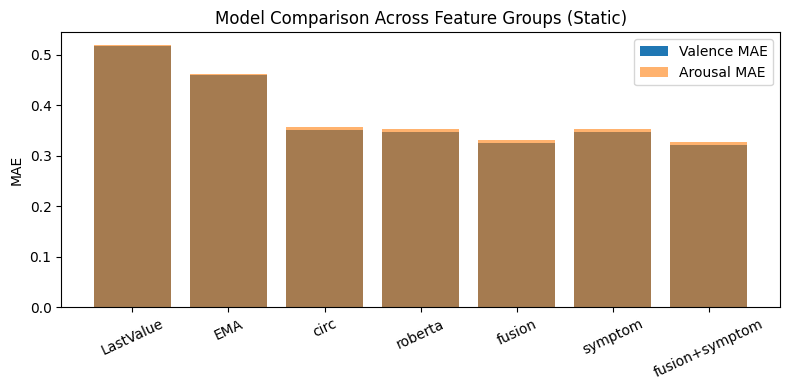

In [ ]:
# Run main evaluations for all feature sets
sets_to_run = [
    ("circ", circ_feats),
    ("roberta", roberta_feats),
    ("fusion", fusion_feats),
    ("symptom", symptom_feats),
    ("fusion+symptom", fusion_feats + symptom_feats)
]

all_results = []
rolling_macros = {}

for name, feats in sets_to_run:
    print(f"\n=== Evaluating {name.upper()} ===")
    row = evaluate_feature_set(merged, feats, label=name, H=2)
    all_results.append(row)

    # Per-user rolling evaluation
    per_user, macro = rolling_eval(merged, feats, H=2)
    rolling_macros[name] = macro

#  Combine into DataFrame
summary = pd.DataFrame(all_results,
                       columns=["FeatureSet","n_feats","MAE_V","MAE_A","DirAcc_V","DirAcc_A"])

summary["MAE_V_roll"] = summary["FeatureSet"].map(lambda k: rolling_macros.get(k,{}).get("mae_v",np.nan))
summary["MAE_A_roll"] = summary["FeatureSet"].map(lambda k: rolling_macros.get(k,{}).get("mae_a",np.nan))
summary["DirAcc_V_roll"] = summary["FeatureSet"].map(lambda k: rolling_macros.get(k,{}).get("dir_acc_v",np.nan))
summary["DirAcc_A_roll"] = summary["FeatureSet"].map(lambda k: rolling_macros.get(k,{}).get("dir_acc_a",np.nan))

# Baselines
df_base, _, _ = build_features(merged, fusion_feats, H=2)
y_v = df_base["v_true_mean_level_t+2"]; y_a = df_base["a_true_mean_level_t+2"]
lv_v = lastvalue_baseline(df_base, "v_true_mean_rm2")
lv_a = lastvalue_baseline(df_base, "a_true_mean_rm2")
ema_v = ema_baseline(df_base, "v_true_mean_rm2", span=3)
ema_a = ema_baseline(df_base, "a_true_mean_rm2", span=3)
mae_lv_v = np.mean(np.abs(y_v - lv_v)); mae_lv_a = np.mean(np.abs(y_a - lv_a))
mae_ema_v = np.mean(np.abs(y_v - ema_v)); mae_ema_a = np.mean(np.abs(y_a - ema_a))

baseline_rows = [
    ["LastValue", 0, mae_lv_v, mae_lv_a, np.nan, np.nan, np.nan, np.nan, np.nan, np.nan],
    ["EMA", 0, mae_ema_v, mae_ema_a, np.nan, np.nan, np.nan, np.nan, np.nan, np.nan]
]

baseline_df = pd.DataFrame(baseline_rows,
    columns=["FeatureSet","n_feats","MAE_V","MAE_A","DirAcc_V","DirAcc_A",
             "MAE_V_roll","MAE_A_roll","DirAcc_V_roll","DirAcc_A_roll"])

summary_all = pd.concat([baseline_df, summary], ignore_index=True)
display(summary_all.round(3))

# Visualization
import matplotlib.pyplot as plt

plt.figure(figsize=(8,4))
plt.bar(summary_all["FeatureSet"], summary_all["MAE_V"], label="Valence MAE")
plt.bar(summary_all["FeatureSet"], summary_all["MAE_A"], alpha=0.6, label="Arousal MAE")
plt.xticks(rotation=25)
plt.ylabel("MAE")
plt.title("Model Comparison Across Feature Groups (Static)")
plt.legend()
plt.tight_layout()
plt.show()


# User grouping + Trajectory

In [22]:
BEST_FEATS = fusion_feats
H = 2

df_an, mr_feats, target_cols = build_features(merged, BEST_FEATS, H=H)

# Convenience names
y_v = f'v_true_mean_level_t+{H}'
y_a = f'a_true_mean_level_t+{H}'
dir_v = f'v_true_mean_dir_t+{H}'
dir_a = f'a_true_mean_dir_t+{H}'

In [23]:
def permutation_importance_arx(df, feats, y_col, level_col, n_repeats=5, seed=42):
    """Shuffles each feature *within user_id blocks* and measures MAE lift."""
    rng = np.random.default_rng(seed)
    base_v = fit_personalized_arx(df, y_col, level_col, feats)
    y_pred = predict_personalized(base_v, df, level_col, feats)
    base_mae = np.mean(np.abs(df[y_col].to_numpy() - y_pred))

    lifts = []
    for f in feats:
        mae_runs = []
        for _ in range(n_repeats):
            df_shuf = df.copy()
            # block-shuffle within users (keeps per-user distribution)
            df_shuf[f] = df_shuf.groupby("user_id")[f].transform(lambda s: rng.permutation(s.to_numpy()))
            v_mod = fit_personalized_arx(df_shuf, y_col, level_col, feats)
            y_hat = predict_personalized(v_mod, df_shuf, level_col, feats)
            mae_runs.append(np.mean(np.abs(df_shuf[y_col].to_numpy() - y_hat)))
        lifts.append((f, np.mean(mae_runs) - base_mae))
    imp = pd.DataFrame(lifts, columns=["feature","mae_lift"]).sort_values("mae_lift", ascending=False)
    return base_mae, imp

base_mae_v, imp_v = permutation_importance_arx(df_an, mr_feats, y_v, 'v_true_mean_rm2', n_repeats=3)
base_mae_a, imp_a = permutation_importance_arx(df_an, mr_feats, y_a, 'a_true_mean_rm2', n_repeats=3)

print("Valence base MAE:", round(base_mae_v,3))
display(imp_v.head(15))
print("Arousal base MAE:", round(base_mae_a,3))
display(imp_a.head(15))

Valence base MAE: 0.325


,feature,mae_lift
35,a_true_mean_rm2_slope3,0.000916
36,v_true_mean_rm2_std4,0.000270
15,empath_help_mean_z,0.000210
37,a_true_mean_rm2_std4,0.000108
2,radius_w,0.000082
23,empath_therapy_mean_z,0.000080
25,empath_anger_mean_z,0.000046
24,empath_sleep_mean_z,0.000019
9,a_hat_mean_ema3,-0.000001
16,empath_love_mean_z,-0.000053


Arousal base MAE: 0.331


,feature,mae_lift
34,v_true_mean_rm2_slope3,0.001177
36,v_true_mean_rm2_std4,0.000638
14,empath_depression_mean_z,0.000339
37,a_true_mean_rm2_std4,0.000269
27,empath_optimism_mean_z,0.000006
7,r_hat_mean,-0.000054
29,posts_true_ema3,-0.000064
24,empath_sleep_mean_z,-0.000082
21,empath_trust_mean_z,-0.000120
15,empath_help_mean_z,-0.000147


In [ ]:
per_user, macro = rolling_eval(merged, BEST_FEATS, H=H)
per_user = per_user.rename(columns={'user':'user_id'})

# Aggregate user descriptors
agg = (df_an
       .groupby('user_id')
       .agg(
         posts=('posts_true','mean'),
         v_vol=('v_true_mean_rm2','std'),
         a_vol=('a_true_mean_rm2','std'),
         anx=('anx_score','mean'), dep=('dep_score','mean'),
         ptsd=('ptsd_score','mean'), mania=('mania_score','mean'),
         sui=('sui_score','mean')
       ).reset_index())

user_summary = per_user.merge(agg, on='user_id', how='left')

# Simple correlations
corr_cols = ['mae_v','mae_a','dir_acc_v','dir_acc_a','posts','v_vol','a_vol','anx','dep','ptsd','mania','sui']
display(user_summary[corr_cols].corr().round(2))

import statsmodels.api as sm
X = user_summary[['posts','v_vol','a_vol','anx','dep','ptsd','mania','sui']].fillna(0.0)
X = sm.add_constant(X)
m = sm.OLS(user_summary['mae_v'], X).fit()
print(m.summary())


,mae_v,mae_a,dir_acc_v,dir_acc_a,posts,v_vol,a_vol,anx,dep,ptsd,mania,sui
mae_v,1.00,0.44,-0.25,-0.01,-0.33,0.65,0.46,-0.27,0.14,-0.22,-0.02,-0.00
mae_a,0.44,1.00,0.08,-0.21,-0.28,0.50,0.75,-0.23,0.13,-0.17,-0.18,-0.04
dir_acc_v,-0.25,0.08,1.00,0.16,0.06,0.02,0.11,0.06,0.15,0.07,-0.23,0.06
dir_acc_a,-0.01,-0.21,0.16,1.00,0.02,-0.02,-0.10,0.05,0.04,0.10,-0.03,0.13
posts,-0.33,-0.28,0.06,0.02,1.00,-0.18,-0.28,-0.08,-0.24,-0.15,-0.03,-0.23
v_vol,0.65,0.50,0.02,-0.02,-0.18,1.00,0.56,-0.28,0.06,-0.25,-0.01,-0.10
a_vol,0.46,0.75,0.11,-0.10,-0.28,0.56,1.00,-0.28,0.18,-0.21,-0.20,-0.08
anx,-0.27,-0.23,0.06,0.05,-0.08,-0.28,-0.28,1.00,0.19,0.91,0.21,0.41
dep,0.14,0.13,0.15,0.04,-0.24,0.06,0.18,0.19,1.00,0.31,-0.14,0.72
ptsd,-0.22,-0.17,0.07,0.10,-0.15,-0.25,-0.21,0.91,0.31,1.00,0.06,0.53


                            OLS Regression Results                            
Dep. Variable:                  mae_v   R-squared:                       0.490
Model:                            OLS   Adj. R-squared:                  0.454
Method:                 Least Squares   F-statistic:                     13.70
Date:                Thu, 06 Nov 2025   Prob (F-statistic):           8.95e-14
Time:                        19:57:53   Log-Likelihood:               -0.56853
No. Observations:                 123   AIC:                             19.14
Df Residuals:                     114   BIC:                             44.45
Df Model:                           8                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0350      0.417      0.084      0.9

In [ ]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

feat_clust = user_summary[['anx','dep','ptsd','mania','sui','v_vol','a_vol','posts']].fillna(0.0)
sc = StandardScaler()
Xz = sc.fit_transform(feat_clust)

best_k, best_s, best_model = None, -1, None
for k in [3,4,5,6]:
    km = KMeans(n_clusters=k, n_init=20, random_state=42)
    lab = km.fit_predict(Xz)
    s = silhouette_score(Xz, lab)
    if s > best_s:
        best_k, best_s, best_model = k, s, km

labels = best_model.predict(Xz)
user_clusters = user_summary[['user_id']].copy()
user_clusters['cluster'] = labels
print(f"Chosen k={best_k}, silhouette={best_s:.3f}")

# Cluster centroids
cent = pd.DataFrame(sc.inverse_transform(best_model.cluster_centers_), 
                    columns=feat_clust.columns)
cent['cluster'] = range(best_k)
display(cent.round(3))


Chosen k=4, silhouette=0.223


,anx,dep,ptsd,mania,sui,v_vol,a_vol,posts,cluster
0,0.272,0.282,0.298,0.261,0.350,0.747,0.730,2.218,0
1,0.386,0.274,0.396,0.293,0.370,0.439,0.391,2.631,1
2,0.341,0.314,0.377,0.251,0.418,0.429,0.468,2.345,2
3,0.283,0.260,0.291,0.264,0.326,0.445,0.437,3.828,3


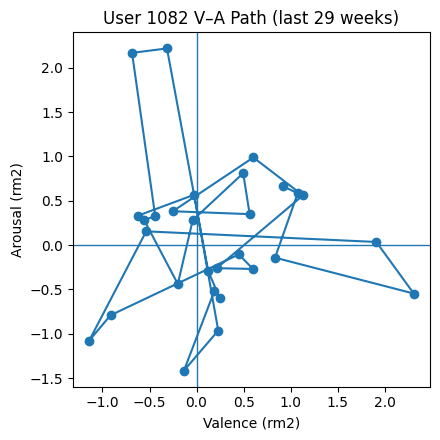

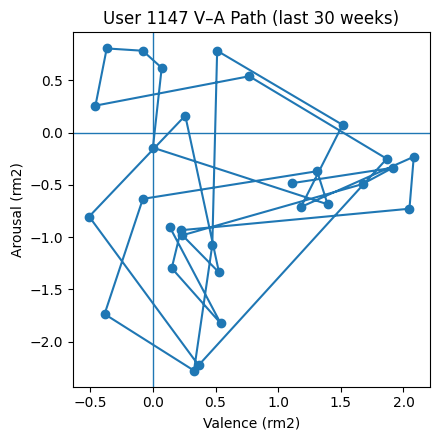

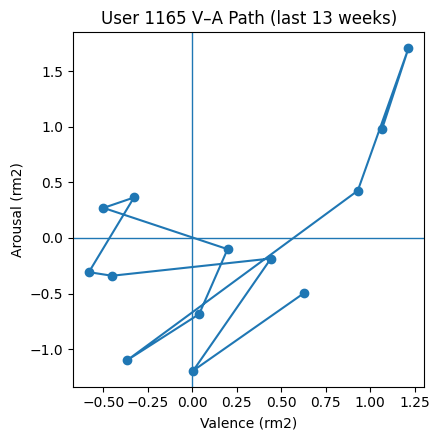

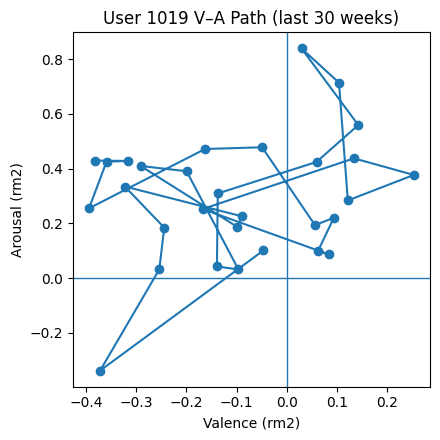

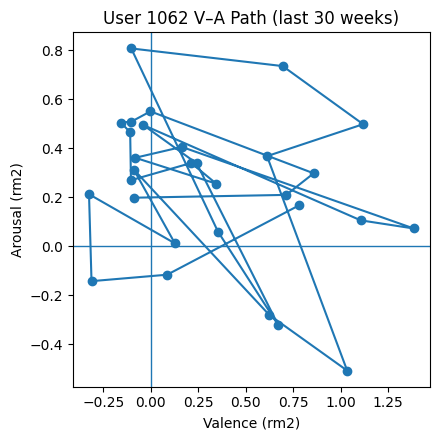

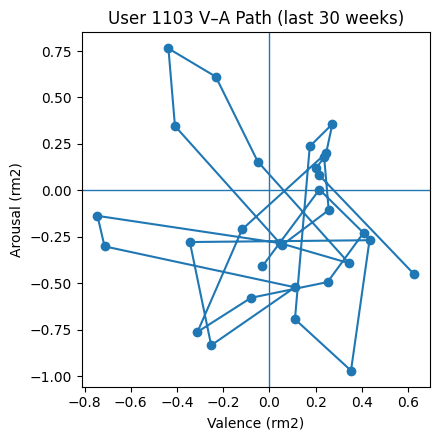

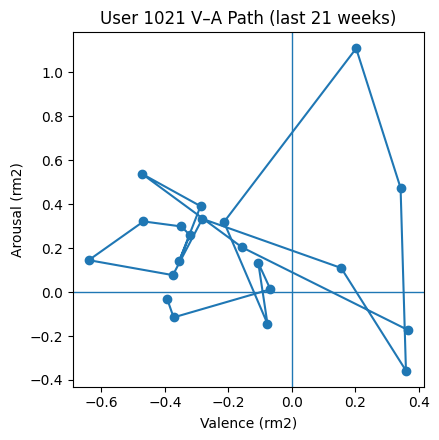

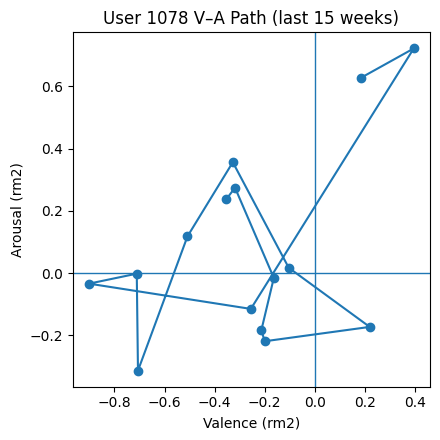

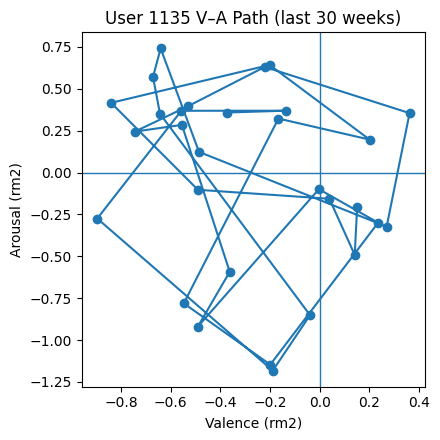

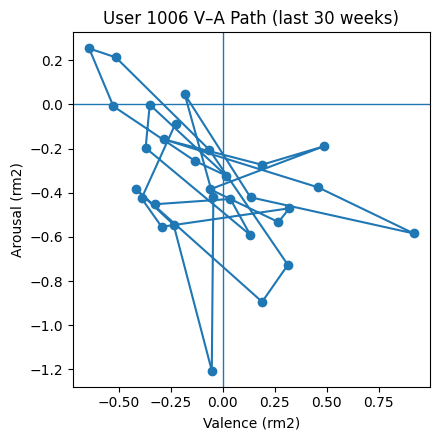

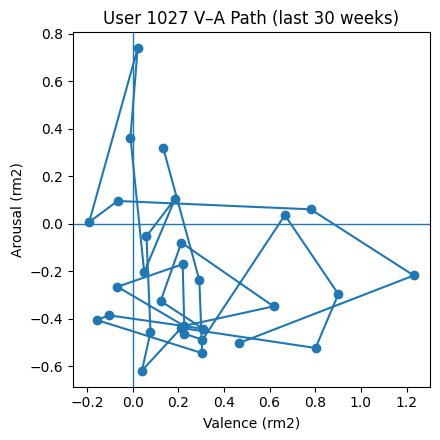

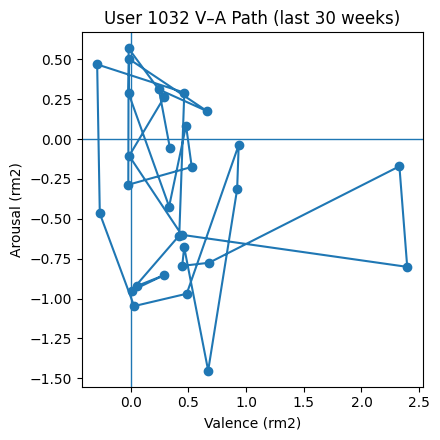

In [26]:
def plot_va_path(df, uid, max_weeks=30):
    d = df[df['user_id']==uid].sort_values('week').tail(max_weeks)
    v, a = d['v_true_mean_rm2'].to_numpy(), d['a_true_mean_rm2'].to_numpy()
    plt.figure(figsize=(4.5,4.5))
    plt.plot(v, a, marker='o')
    plt.axhline(0, lw=1); plt.axvline(0, lw=1)
    plt.xlabel('Valence (rm2)'); plt.ylabel('Arousal (rm2)')
    plt.title(f'User {uid} V–A Path (last {len(d)} weeks)')
    plt.tight_layout(); plt.show()

# pick 2–3 representatives per cluster
for c in range(best_k):
    samp = user_clusters[user_clusters['cluster']==c]['user_id'].head(3)
    for uid in samp:
        plot_va_path(df_an, uid)


In [ ]:
def flag_episodes(df, col='v_true_mean_rm2', span=5, z=1.0):
    out = df.copy()
    out['ema'] = out.groupby('user_id')[col].transform(lambda s: s.ewm(span=span, adjust=False).mean())
    resid = out[col] - out['ema']
    zres  = (resid - resid.groupby(out['user_id']).transform('mean')) / \
            (resid.groupby(out['user_id']).transform('std').replace(0,1e-6))
    out['episode_flag'] = (np.abs(zres) > z).astype(int)
    return out

episodes = flag_episodes(df_an, 'a_true_mean_rm2', span=5, z=1.2)
episode_rate = (episodes.groupby('user_id')['episode_flag'].mean()
                .reset_index(name='episode_rate'))
display(episode_rate.describe())

# Link episode rate to error
ep_join = user_summary.merge(episode_rate, on='user_id', how='left')
print("Corr(episode_rate, mae_v):", ep_join[['episode_rate','mae_v']].corr().iloc[0,1].round(3))


,user_id,episode_rate
count,577.000000,577.000000
mean,3268.168111,0.108356
std,1764.878323,0.122882
min,1004.000000,0.000000
25%,1774.000000,0.000000
50%,2863.000000,0.000000
75%,4633.000000,0.214286
max,7310.000000,0.500000


Corr(episode_rate, mae_v): 0.155


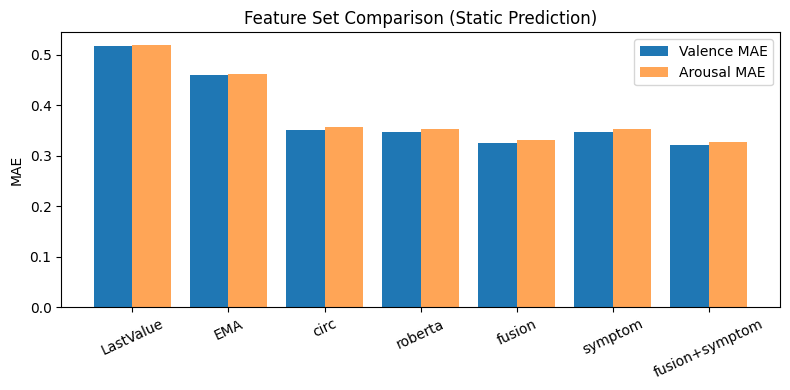

In [28]:
# Visualization of overall results
plt.figure(figsize=(8,4))
x = np.arange(len(summary_all["FeatureSet"]))
plt.bar(x - 0.2, summary_all["MAE_V"], width=0.4, label="Valence MAE")
plt.bar(x + 0.2, summary_all["MAE_A"], width=0.4, label="Arousal MAE", alpha=0.7)
plt.xticks(x, summary_all["FeatureSet"], rotation=25)
plt.ylabel("MAE")
plt.title("Feature Set Comparison (Static Prediction)")
plt.legend()
plt.tight_layout()
plt.show()

/var/folders/0l/qgn1vqn15c3gw9rx0_bhcwq40000gn/T/ipykernel_97032/1235636757.py:3: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([per_user['mae_v'], per_user['mae_a']], labels=['Valence','Arousal'])


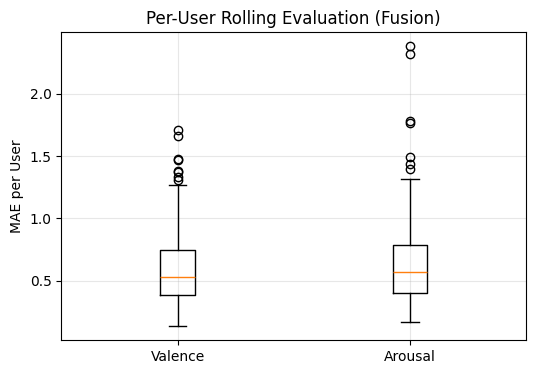

In [29]:
# Rolling Eval
plt.figure(figsize=(6,4))
plt.boxplot([per_user['mae_v'], per_user['mae_a']], labels=['Valence','Arousal'])
plt.ylabel('MAE per User')
plt.title('Per-User Rolling Evaluation (Fusion)')
plt.grid(alpha=0.3)
plt.show()


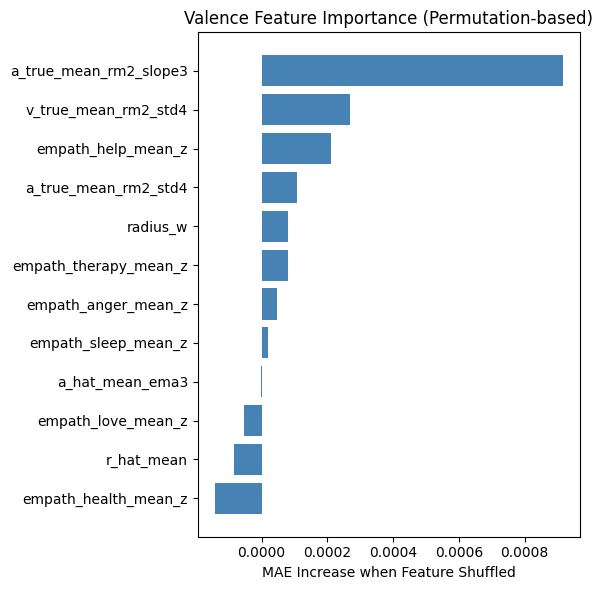

In [30]:
# Feature Importance
plt.figure(figsize=(6,6))
plt.barh(imp_v['feature'].head(12)[::-1], imp_v['mae_lift'].head(12)[::-1], color='steelblue')
plt.xlabel("MAE Increase when Feature Shuffled")
plt.title("Valence Feature Importance (Permutation-based)")
plt.tight_layout()
plt.show()

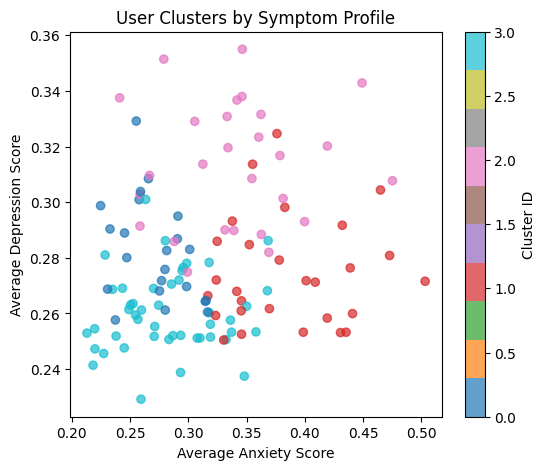

In [31]:
def safe_cluster_plot(agg, user_clusters):
    # Ensure proper alignment
    plot_data = agg.merge(user_clusters, on='user_id', how='inner')
    
    plt.figure(figsize=(6,5))
    scatter = plt.scatter(plot_data['anx'], plot_data['dep'], 
                         c=plot_data['cluster'], cmap='tab10', alpha=0.7)
    plt.colorbar(scatter, label='Cluster ID')
    plt.xlabel('Average Anxiety Score')
    plt.ylabel('Average Depression Score')
    plt.title('User Clusters by Symptom Profile')
    plt.show()
safe_cluster_plot(agg, user_clusters)

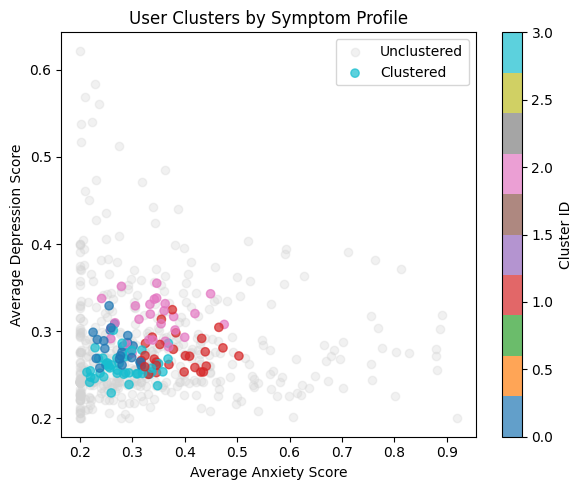

In [32]:
agg_full = agg.merge(user_clusters, on='user_id', how='left')

plt.figure(figsize=(6,5))
# Plot unclustered users in gray
mask_unclustered = agg_full['cluster'].isna()
plt.scatter(agg_full.loc[mask_unclustered, 'anx'], 
           agg_full.loc[mask_unclustered, 'dep'], 
           c='lightgray', alpha=0.3, label='Unclustered')

# Plot clustered users with colors
mask_clustered = ~mask_unclustered
plt.scatter(agg_full.loc[mask_clustered, 'anx'],
           agg_full.loc[mask_clustered, 'dep'],
           c=agg_full.loc[mask_clustered, 'cluster'], 
           cmap='tab10', alpha=0.7, label='Clustered')

plt.xlabel('Average Anxiety Score')
plt.ylabel('Average Depression Score')
plt.title('User Clusters by Symptom Profile')
plt.colorbar(label='Cluster ID')
plt.legend()
plt.tight_layout()
plt.show()

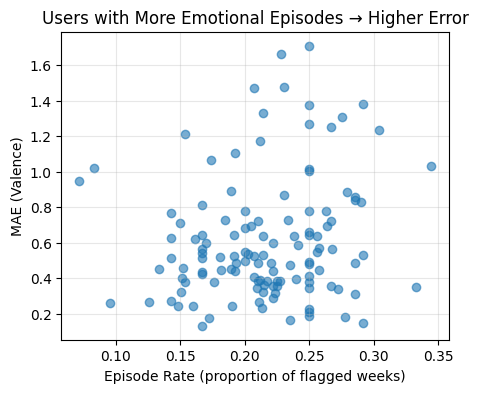

In [33]:
plt.figure(figsize=(5,4))
plt.scatter(ep_join['episode_rate'], ep_join['mae_v'], alpha=0.6)
plt.xlabel("Episode Rate (proportion of flagged weeks)")
plt.ylabel("MAE (Valence)")
plt.title("Users with More Emotional Episodes → Higher Error")
plt.grid(alpha=0.3)
plt.show()

In [ ]:
from sklearn.linear_model import Ridge
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline

# Build the feature-ready dataset
BEST_FEATS = fusion_feats + symptom_feats
H = 2
df_explain, mr_feats, target_cols = build_features(merged, BEST_FEATS, H=H)

# Drop rows with NaNs
df_explain = df_explain.dropna(subset=[f"v_true_mean_level_t+{H}", "v_true_mean_rm2"]).copy()

X = df_explain[mr_feats].fillna(0)
y_v = df_explain[f"v_true_mean_level_t+{H}"]
y_a = df_explain[f"a_true_mean_level_t+{H}"]

# Use Ridge for small regularization
model_v = make_pipeline(StandardScaler(), Ridge(alpha=0.5))
model_v.fit(X, y_v)
model_a = make_pipeline(StandardScaler(), Ridge(alpha=0.5))
model_a.fit(X, y_a)


,steps,"[('standardscaler', ...), ('ridge', ...)]"
,transform_input,None
,memory,None
,verbose,False
,copy,True
,with_mean,True
,with_std,True
,alpha,0.5
,fit_intercept,True
,copy_X,True
,max_iter,None


# SHAP

In [54]:
import shap
import pickle
import os
import re
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.pipeline import Pipeline
from sklearn.linear_model import Ridge
from sklearn.preprocessing import StandardScaler

In [ ]:
# Extract results from your existing analysis
notebook_results = {
    "evaluation_results": {
        "summary_all": summary_all,
        "feature_sets_used": {
            'circ': circ_feats,
            'roberta': roberta_feats,
            'fusion': fusion_feats,
            'symptom': symptom_feats,
            'fusion+symptom': fusion_feats + symptom_feats
        },
        "best_features": BEST_FEATS,
        "performance_metrics": summary_all.to_dict('records')
    },
    
    "rolling_evaluation": {
        "fusion_macro": macro,  # From your rolling_eval call
        "fusion_per_user": per_user.to_dict('records')
    },
    
    "feature_importance": {
        "valence": imp_v.to_dict('records'),
        "arousal": imp_a.to_dict('records')
    },
    
    "user_analysis": {
        "clusters": user_clusters.to_dict('records') if 'user_clusters' in locals() else None,
        "cluster_centroids": cent.to_dict('records') if 'cent' in locals() else None,
        "user_summary": user_summary.to_dict('records') if 'user_summary' in locals() else None
    },
    
    # Store the models for potential future use
    "simple_models": {
        "model_v": model_v,
        "model_a": model_a,
        "X_cols": mr_feats,
        "H": H,
        "df_explain": df_explain
    },
    
    # Metadata
    "metadata": {
        "data_shape": df_an.shape,
        "n_users": df_an['user_id'].nunique(),
        "feature_counts": {
            'circ': len(circ_feats),
            'roberta': len(roberta_feats), 
            'fusion': len(fusion_feats),
            'symptom': len(symptom_feats),
            'fusion+symptom': len(fusion_feats + symptom_feats)
        }
    }
}

# Save the notebook results
with open("./data/notebook_arx_results.pkl", 'wb') as f:
    pickle.dump(notebook_results, f)

print(" Saved notebook analysis results to ./data/notebook_arx_results.pkl")

# Display summary for verification
print("\n=== NOTEBOOK RESULTS SUMMARY ===")
print(f"Data shape: {notebook_results['metadata']['data_shape']}")
print(f"Number of users: {notebook_results['metadata']['n_users']}")
print(f"Feature set sizes: {notebook_results['metadata']['feature_counts']}")

print("\n=== PERFORMANCE METRICS ===")
performance_df = pd.DataFrame(notebook_results['evaluation_results']['performance_metrics'])
display(performance_df[['FeatureSet', 'MAE_V', 'MAE_A', 'DirAcc_V', 'DirAcc_A']].round(4))

print("\n=== ROLLING EVALUATION (FUSION) ===")
if 'rolling_evaluation' in notebook_results:
    print("Macro metrics:", notebook_results['rolling_evaluation']['fusion_macro'])

print(" Results ready for comparison with ARX pipeline!")

 Saved notebook analysis results to ./data/notebook_arx_results.pkl

=== NOTEBOOK RESULTS SUMMARY ===
Data shape: (7397, 61)
Number of users: 577
Feature set sizes: {'circ': 5, 'roberta': 5, 'fusion': 30, 'symptom': 5, 'fusion+symptom': 35}

=== PERFORMANCE METRICS ===


,FeatureSet,MAE_V,MAE_A,DirAcc_V,DirAcc_A
0,LastValue,0.5173,0.5182,NaN,NaN
1,EMA,0.4590,0.4620,NaN,NaN
2,circ,0.3507,0.3576,0.6193,0.6088
3,roberta,0.3467,0.3520,0.6225,0.6124
4,fusion,0.3253,0.3313,0.6485,0.6372
5,symptom,0.3479,0.3533,0.6244,0.6151
6,fusion+symptom,0.3219,0.3264,0.6524,0.6436



=== ROLLING EVALUATION (FUSION) ===
Macro metrics: {'mae_v': 0.6124167725590658, 'mae_a': 0.6467267130812584, 'dir_acc_v': 0.46097834836555995, 'dir_acc_a': 0.471353446361971}
 Results ready for comparison with ARX pipeline!


In [ ]:
BUNDLE_PATH = "./data/notebook_arx_results.pkl"

have_bundle = os.path.exists(BUNDLE_PATH)
print("Found bundle:", have_bundle)

if os.path.exists(BUNDLE_PATH):
    with open(BUNDLE_PATH, 'rb') as f:
        bundle = pickle.load(f)
    
    if 'simple_models' in bundle:
        model_v = bundle['simple_models']['model_v'] 
        model_a = bundle['simple_models']['model_a']  
        df_explain = bundle['simple_models']['df_explain']
        X_cols = bundle['simple_models']['X_cols']
        H = bundle['simple_models']['H']
    else:
        # Direct access if not nested
        model_v = bundle['model_v']  
        model_a = bundle['model_a'] 
        df_explain = bundle['df_explain']
        X_cols = bundle['X_cols']
        H = bundle['H']

else:
    BEST_FEATS = fusion_feats + symptom_feats
    H = 2
    df_explain, X_cols, _ = build_features(merged, BEST_FEATS, H=H)
    df_explain = df_explain.dropna(subset=[f"v_true_mean_level_t+{H}", "v_true_mean_rm2"]).copy()

    from sklearn.pipeline import make_pipeline
    model_v = make_pipeline(StandardScaler(with_mean=True), Ridge(alpha=0.5, random_state=42))
    model_a = make_pipeline(StandardScaler(with_mean=True), Ridge(alpha=0.5, random_state=42))

    X_tmp = df_explain[X_cols].fillna(0)
    y_v = df_explain[f"v_true_mean_level_t+{H}"]
    y_a = df_explain[f"a_true_mean_level_t+{H}"]
    model_v.fit(X_tmp, y_v)
    model_a.fit(X_tmp, y_a)

    joblib.dump({
        "model_v": model_v,
        "model_a": model_a,
        "X_cols": X_cols,
        "H": H,
        "df_explain": df_explain
    }, BUNDLE_PATH)
    print("Saved ARX pipeline to", BUNDLE_PATH)

# Build feature matrix
X = df_explain[X_cols].fillna(0)
print("X shape:", X.shape, "| n_features:", len(X_cols))

# Ensure no future target in features
assert not any(c.endswith(f"_t+{H}") for c in X.columns), "Target leakage: *_t+H in features!"


Found bundle: True
X shape: (7397, 43) | n_features: 43


In [ ]:
def split_linear_pipeline(pipeline: Pipeline):
    try:
        scaler = None
        linear = None
        
        for name, step in pipeline.named_steps.items():
            if isinstance(step, StandardScaler):
                scaler = step
            elif isinstance(step, Ridge):
                linear = step
                
        if scaler is None or linear is None:
            raise ValueError(f"Pipeline must contain StandardScaler and Ridge. Found: {list(pipeline.named_steps.keys())}")
            
        return scaler, linear
    except Exception as e:
        print(f"Pipeline extraction failed: {e}")
        print(f"Pipeline steps: {list(pipeline.named_steps.keys())}")
        raise

# Extract pipeline components
try:
    scaler_v, ridge_v = split_linear_pipeline(model_v)
    scaler_a, ridge_a = split_linear_pipeline(model_a)
    print("Pipeline components extracted successfully")
except Exception as e:
    print(f"Error extracting pipeline: {e}")
    # check if models are already Ridge objects
    if hasattr(model_v, 'coef_'):
        ridge_v, ridge_a = model_v, model_a
        scaler_v = scaler_a = None
        print("Using models directly")
    else:
        raise

Pipeline components extracted successfully


In [ ]:
# Transform data if scaler exists
if scaler_v is not None:
    X_v_tr = scaler_v.transform(X)
    X_a_tr = scaler_a.transform(X)
else:
    X_v_tr = X.values
    X_a_tr = X.values

print(f"Data transformed: {X_v_tr.shape}")

# Create background sample for SHAP
rng = np.random.default_rng(42)
bg_size = min(100, len(X))  # Smaller background for speed
bg_idx = rng.choice(len(X), size=bg_size, replace=False)
bg_v = X_v_tr[bg_idx]
bg_a = X_a_tr[bg_idx]

print(f"Background sample created: {bg_size} samples")

# Create SHAP explainers with error handling
try:
    print("Creating SHAP explainers...")
    expl_v = shap.LinearExplainer(ridge_v, bg_v, feature_perturbation="interventional")
    expl_a = shap.LinearExplainer(ridge_a, bg_a, feature_perturbation="interventional")
    
    # Calculate SHAP values
    sample_size = min(500, len(X))
    sample_idx = rng.choice(len(X), size=sample_size, replace=False)
    
    print(f"Calculating SHAP values for {sample_size} samples...")
    shap_v = expl_v.shap_values(X_v_tr[sample_idx])
    shap_a = expl_a.shap_values(X_a_tr[sample_idx])
    
    print(f"SHAP values calculated: V{shap_v.shape}, A{shap_a.shape}")
    
    # Use sampled data for plotting
    X_sample = X.iloc[sample_idx]
    
except Exception as e:
    print(f"SHAP calculation failed: {e}")
    print("Trying alternative approach...")
    
    try:
        explainer_v = shap.Explainer(model_v, X.sample(min(50, len(X)), random_state=42))
        explainer_a = shap.Explainer(model_a, X.sample(min(50, len(X)), random_state=42))
        
        test_sample = X.sample(min(100, len(X)), random_state=42)
        shap_values_v = explainer_v(test_sample)
        shap_values_a = explainer_a(test_sample)
        
        # Extract arrays
        shap_v = shap_values_v.values
        shap_a = shap_values_a.values
        X_sample = test_sample
        
        print(f"Fallback SHAP successful: V{shap_v.shape}, A{shap_a.shape}")
        
    except Exception as e2:
        print(f"Both SHAP methods failed: {e2}")
        raise

Data transformed: (7397, 43)
Background sample created: 100 samples
Creating SHAP explainers...
Calculating SHAP values for 500 samples...
SHAP values calculated: V(500, 43), A(500, 43)


/Users/chiahao/anaconda3/envs/umlt/lib/python3.10/site-packages/shap/explainers/_linear.py:99: FutureWarning: The feature_perturbation option is now deprecated in favor of using the appropriate masker (maskers.Independent, maskers.Partition or maskers.Impute).
  warnings.warn(wmsg, FutureWarning)


Creating SHAP visualizations...


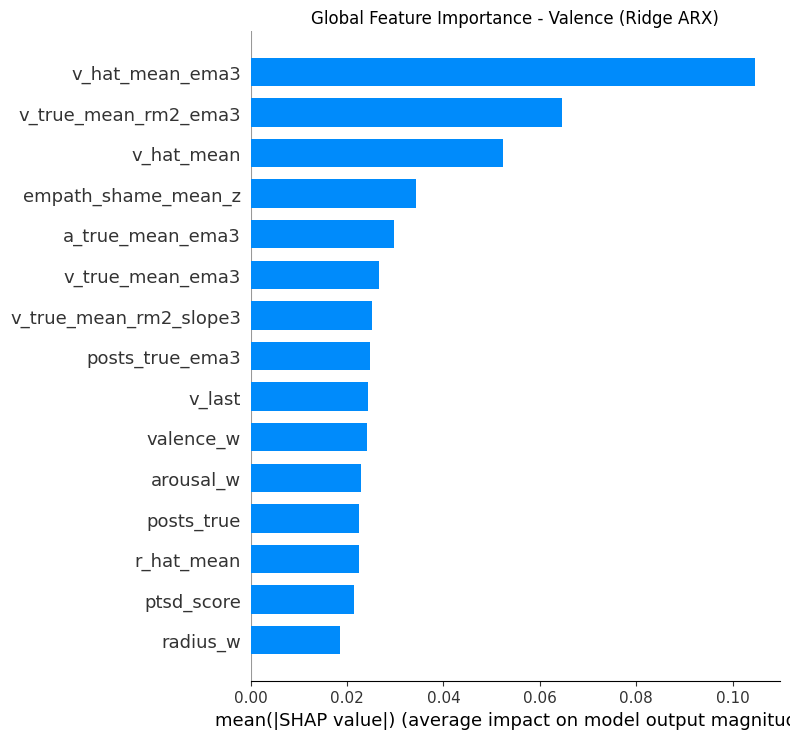

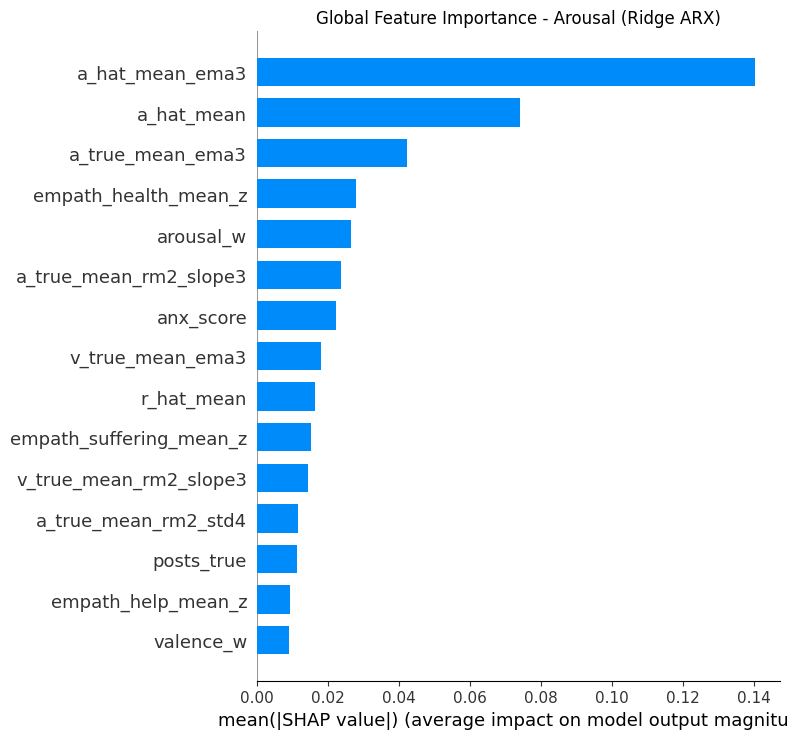

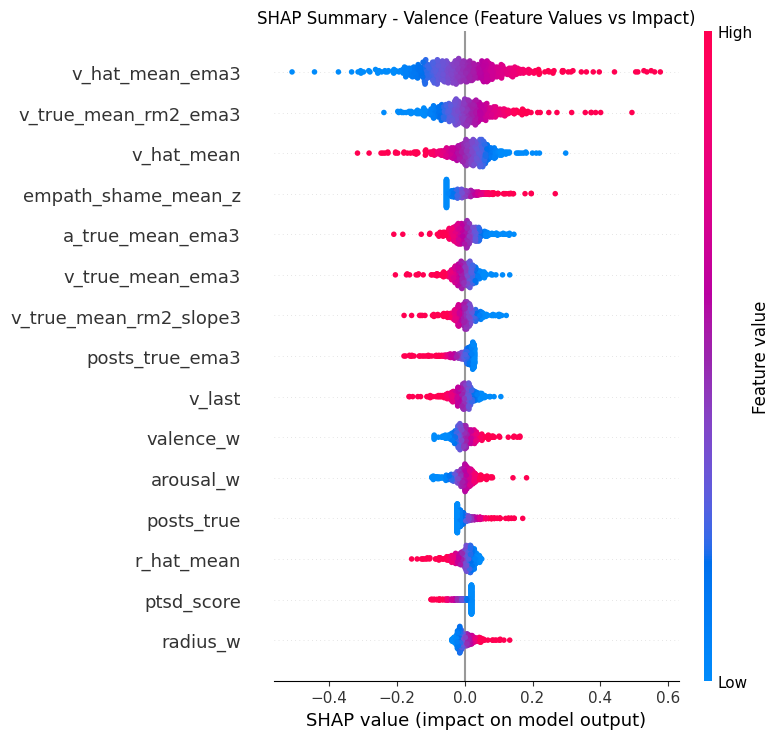

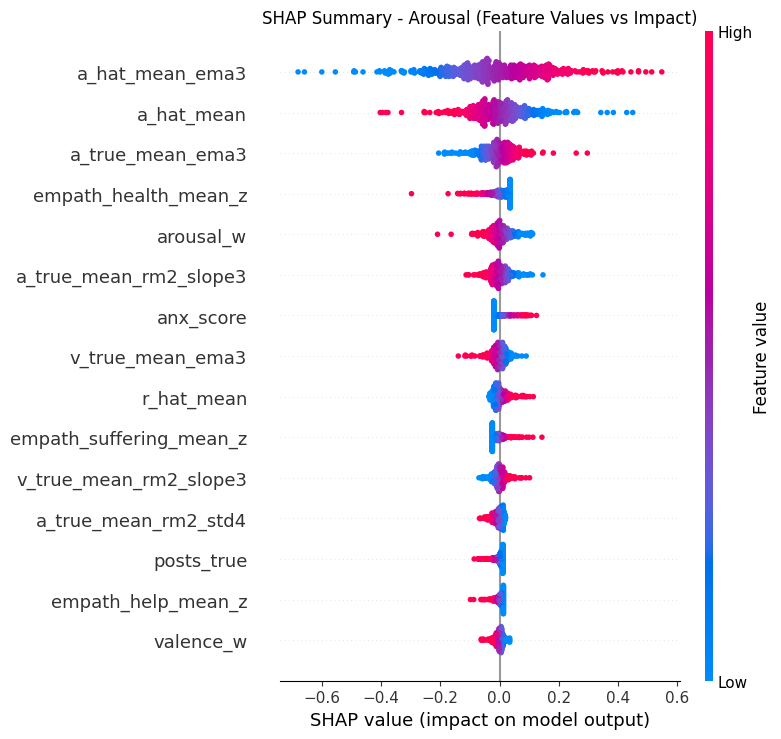

Summary plots completed


In [ ]:
# SHAP visualizations with error handling
try:
    print("Creating SHAP visualizations...")
    
    # Summary plots
    plt.figure(figsize=(10, 6))
    shap.summary_plot(shap_v, X_sample, plot_type="bar", show=False, max_display=15)
    plt.title("Global Feature Importance - Valence (Ridge ARX)")
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(10, 6))
    shap.summary_plot(shap_a, X_sample, plot_type="bar", show=False, max_display=15)
    plt.title("Global Feature Importance - Arousal (Ridge ARX)")
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(10, 8))
    shap.summary_plot(shap_v, X_sample, show=False, max_display=15)
    plt.title("SHAP Summary - Valence (Feature Values vs Impact)")
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(10, 8))
    shap.summary_plot(shap_a, X_sample, show=False, max_display=15)
    plt.title("SHAP Summary - Arousal (Feature Values vs Impact)")
    plt.tight_layout()
    plt.show()

    print("Summary plots completed")

except Exception as e:
    print(f"Summary plots failed: {e}")

In [45]:
def top_k_shap(shap_values, Xdf, k=15):
    vals = np.abs(shap_values).mean(axis=0)
    imp = pd.Series(vals, index=Xdf.columns).sort_values(ascending=False).head(k)
    return imp.reset_index().rename(columns={"index":"feature", 0:"mean_abs_shap"})

top15_v = top_k_shap(shap_v, X, k=15)
top15_a = top_k_shap(shap_a, X, k=15)
display(top15_v); display(top15_a)

top15_v.to_csv("shap_top15_valence.csv", index=False)
top15_a.to_csv("shap_top15_arousal.csv", index=False)
print("Saved shap_top15_valence.csv & shap_top15_arousal.csv")


,feature,mean_abs_shap
0,v_hat_mean_ema3,0.101901
1,v_true_mean_rm2_ema3,0.062160
2,v_hat_mean,0.048452
3,empath_shame_mean_z,0.035740
4,a_true_mean_ema3,0.029462
5,v_true_mean_rm2_slope3,0.025882
6,v_true_mean_ema3,0.025184
7,v_last,0.023854
8,ptsd_score,0.023617
9,valence_w,0.023177


,feature,mean_abs_shap
0,a_hat_mean_ema3,0.143298
1,a_hat_mean,0.074367
2,a_true_mean_ema3,0.041705
3,empath_health_mean_z,0.029698
4,arousal_w,0.026351
5,anx_score,0.024446
6,a_true_mean_rm2_slope3,0.022847
7,v_true_mean_ema3,0.017111
8,empath_suffering_mean_z,0.015682
9,r_hat_mean,0.015437


Saved shap_top15_valence.csv & shap_top15_arousal.csv


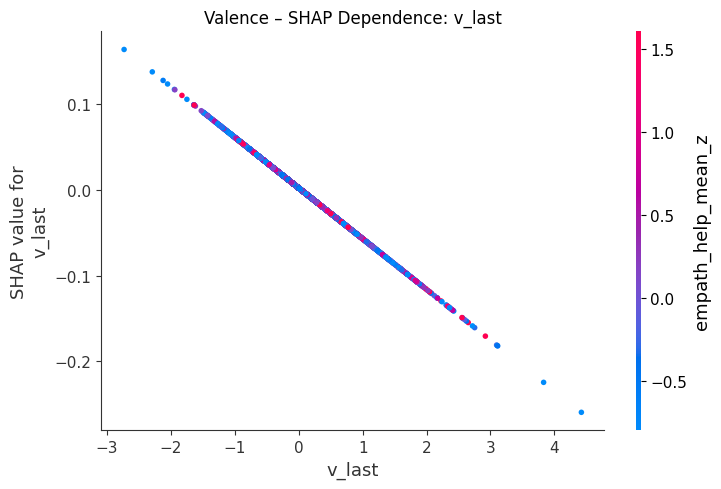

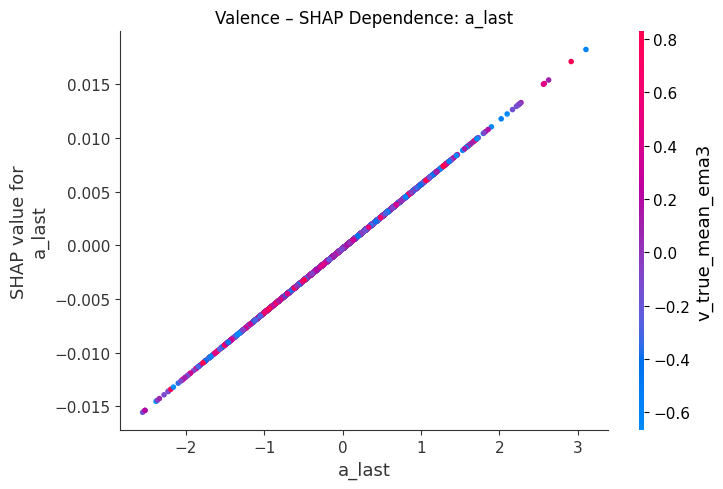

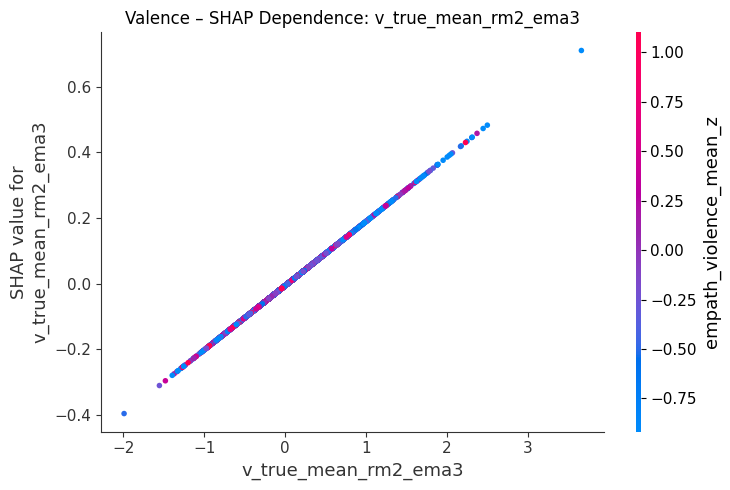

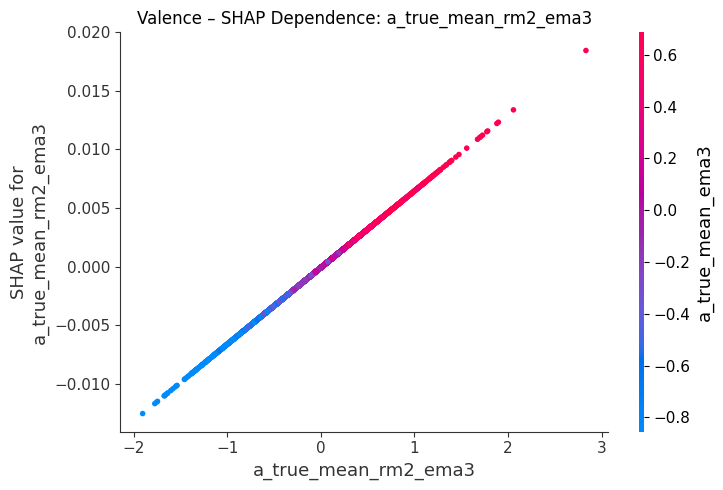

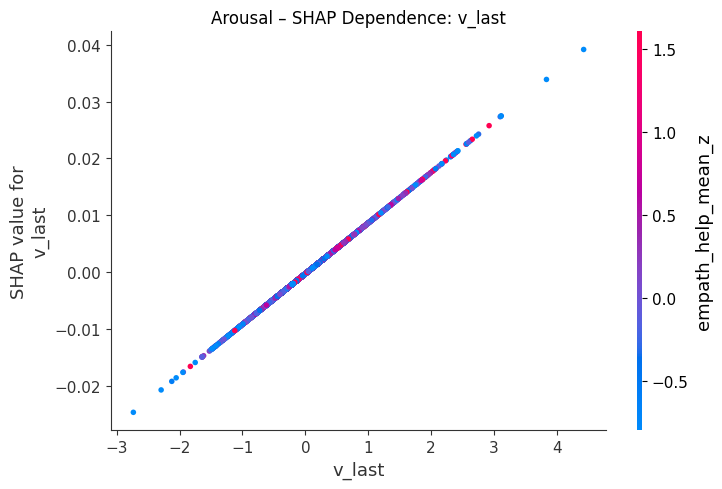

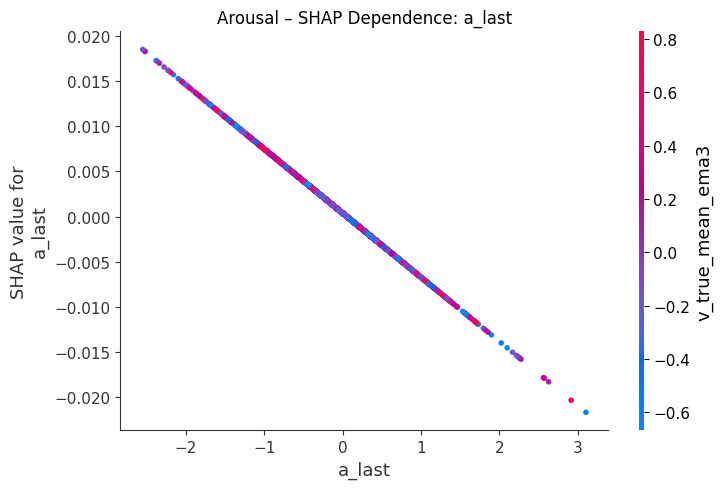

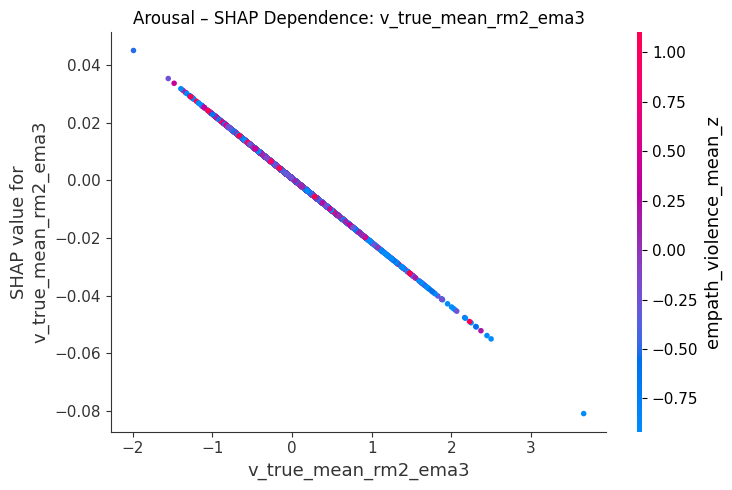

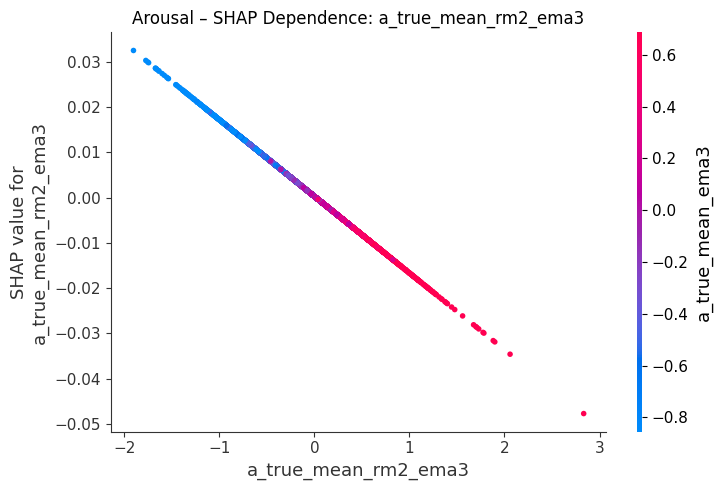

In [46]:
cand_feats = [c for c in [
    "v_last","a_last",
    "v_true_mean_rm2_ema3","a_true_mean_rm2_ema3",
    "v_true_mean_rm2_slope3","a_true_mean_rm2_slope3",
    "v_true_mean_rm2_std4","a_true_mean_rm2_std4"
] if c in X.columns][:4]

for f in cand_feats:
    shap.dependence_plot(f, shap_v, X, feature_names=X.columns, show=False)
    plt.title(f"Valence – SHAP Dependence: {f}")
    plt.tight_layout(); plt.show()

for f in cand_feats:
    shap.dependence_plot(f, shap_a, X, feature_names=X.columns, show=False)
    plt.title(f"Arousal – SHAP Dependence: {f}")
    plt.tight_layout(); plt.show()


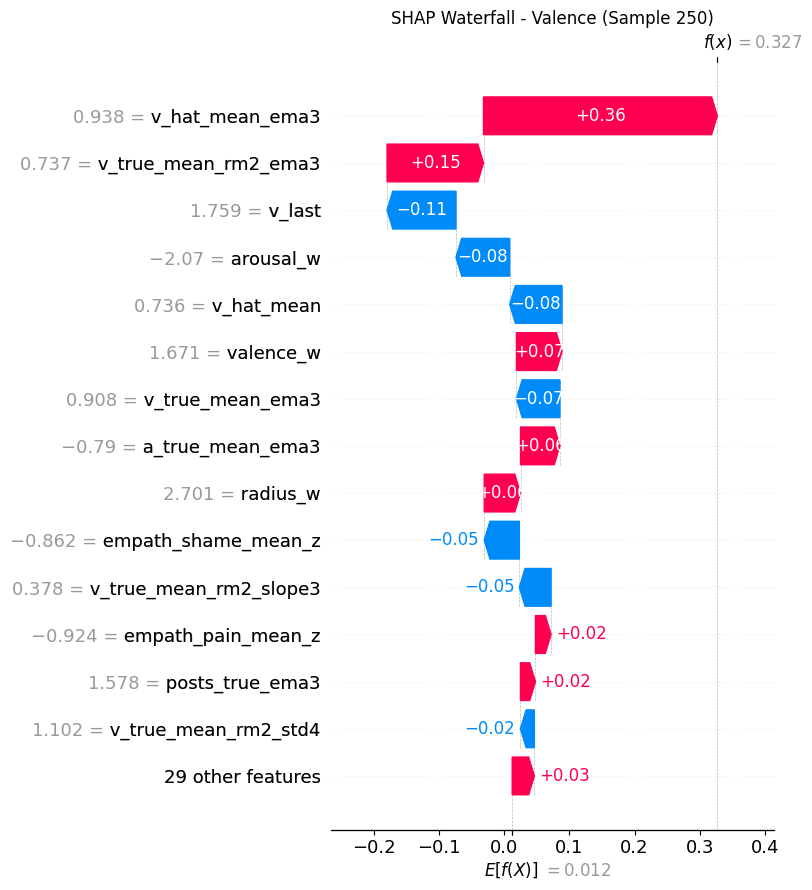

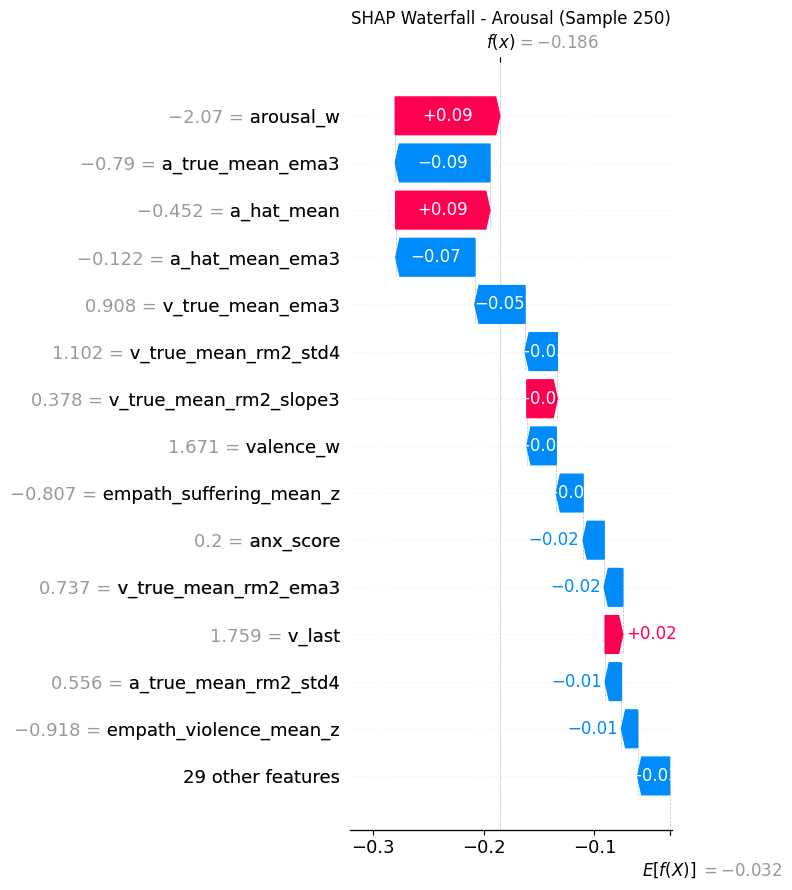

Waterfall plots completed


In [62]:
try:
    sample_idx_local = len(X_sample) // 2  # Middle sample
    
    # Create explanation objects
    explanation_v = shap.Explanation(
        values=shap_v[sample_idx_local],
        base_values=expl_v.expected_value if hasattr(expl_v, 'expected_value') else 0,
        data=X_sample.iloc[sample_idx_local].values,
        feature_names=list(X_sample.columns)
    )
    
    explanation_a = shap.Explanation(
        values=shap_a[sample_idx_local],
        base_values=expl_a.expected_value if hasattr(expl_a, 'expected_value') else 0,
        data=X_sample.iloc[sample_idx_local].values,
        feature_names=list(X_sample.columns)
    )
    
    # Waterfall plots
    plt.figure(figsize=(12, 8))
    shap.waterfall_plot(explanation_v, max_display=15, show=False)
    plt.title(f"SHAP Waterfall - Valence (Sample {sample_idx_local})")
    plt.tight_layout()
    plt.show()
    
    plt.figure(figsize=(12, 8))
    shap.waterfall_plot(explanation_a, max_display=15, show=False)
    plt.title(f"SHAP Waterfall - Arousal (Sample {sample_idx_local})")
    plt.tight_layout()
    plt.show()
    
    print("Waterfall plots completed")
    
except Exception as e:
    print(f"Waterfall plots failed: {e}")
    print("Creating alternative local explanation...")
    
    # Manual local explanation as fallback
    def plot_local_importance(shap_vals, feature_vals, feature_names, title, max_display=15):
        abs_importance = np.abs(shap_vals)
        top_idx = np.argsort(abs_importance)[-max_display:][::-1]
        
        plt.figure(figsize=(10, 6))
        colors = ['red' if x < 0 else 'blue' for x in shap_vals[top_idx]]
        y_pos = np.arange(len(top_idx))
        
        plt.barh(y_pos, shap_vals[top_idx], color=colors, alpha=0.7)
        plt.yticks(y_pos, [f"{feature_names[i]} = {feature_vals[i]:.2f}" for i in top_idx])
        plt.xlabel("SHAP Value")
        plt.title(title)
        plt.axvline(x=0, color='black', linestyle='-', alpha=0.3)
        plt.tight_layout()
        plt.show()
    
    plot_local_importance(shap_v[sample_idx_local], X_sample.iloc[sample_idx_local].values, 
                         X_sample.columns, f"Local SHAP - Valence (Sample {sample_idx_local})")
    plot_local_importance(shap_a[sample_idx_local], X_sample.iloc[sample_idx_local].values,
                         X_sample.columns, f"Local SHAP - Arousal (Sample {sample_idx_local})")

Valence - family importance:


,family,mean_abs_shap,share
5,temporal,0.188921,0.282467
3,roberta,0.182733,0.273215
2,empath,0.148366,0.221829
1,circ,0.065573,0.098042
0,behavior,0.047194,0.070563
4,symptoms,0.036039,0.053884



Arousal - family importance:


,family,mean_abs_shap,share
3,roberta,0.234141,0.401862
5,temporal,0.137221,0.235516
2,empath,0.117385,0.201471
4,symptoms,0.046337,0.079530
1,circ,0.035776,0.061404
0,behavior,0.011779,0.020217


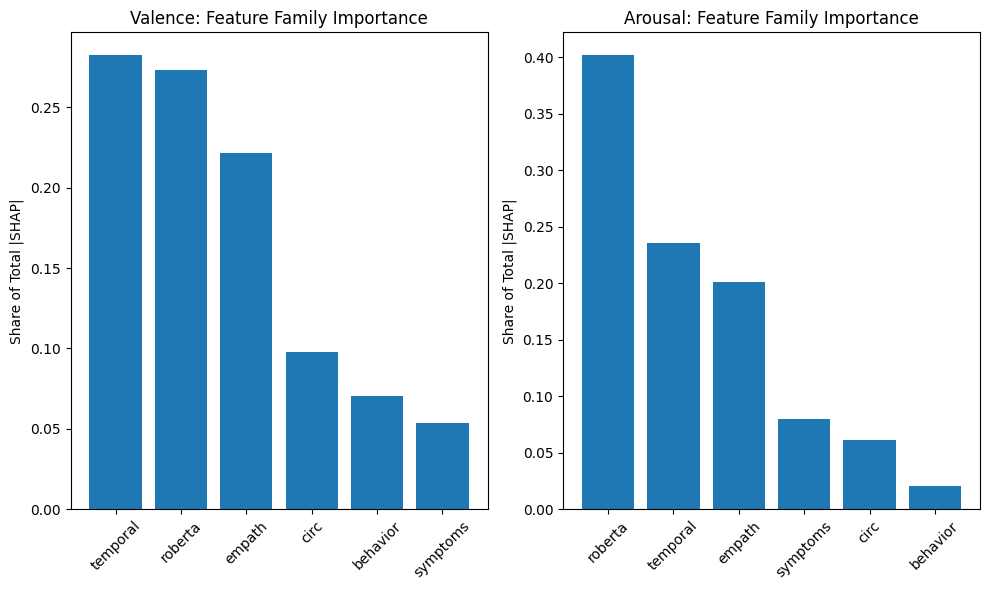

Family analysis completed
SHAP analysis completed!


In [63]:
# Define mutually exclusive families by simple name rules
families = {
    "temporal":  lambda c: bool(re.search(r"(?:_last$|_rm2_|_ema3$|_slope3$|_std4$)", c)),
    "empath":    lambda c: c.startswith("empath_"),
    "roberta":   lambda c: c.startswith(("v_hat_mean","a_hat_mean","r_hat_mean")),
    "circ":      lambda c: c.endswith("_w") and not c.startswith("empath_"),
    "symptoms":  lambda c: c in {"anx_score","dep_score","ptsd_score","mania_score","sui_score"},
    "behavior":  lambda c: c in {"posts_true","posts_true_ema3","posts"}  # keep only those present
}

def family_importance(shap_values, feature_df):
    """Calculate importance by feature family"""
    abs_importance = np.abs(shap_values).mean(axis=0)
    df_imp = pd.DataFrame({
        "feature": feature_df.columns, 
        "mean_abs_shap": abs_importance
    })
    
    # Assign families
    df_imp["family"] = "other"
    for fam_name, rule in families.items():
        mask = df_imp["feature"].apply(rule)
        df_imp.loc[mask, "family"] = fam_name
    
    # Aggregate by family
    family_agg = df_imp.groupby("family", as_index=False)["mean_abs_shap"].sum()
    family_agg["share"] = family_agg["mean_abs_shap"] / family_agg["mean_abs_shap"].sum()
    family_agg = family_agg.sort_values("share", ascending=False)
    
    return df_imp, family_agg

try:
    _, fam_v = family_importance(shap_v, X_sample)
    _, fam_a = family_importance(shap_a, X_sample)
    
    print("Valence - family importance:")
    display(fam_v)
    print("\nArousal - family importance:")
    display(fam_a)
    
    # Plot family importance
    plt.figure(figsize=(10, 6))
    plt.subplot(1, 2, 1)
    plt.bar(fam_v["family"], fam_v["share"])
    plt.title("Valence: Feature Family Importance")
    plt.xticks(rotation=45)
    plt.ylabel("Share of Total |SHAP|")
    
    plt.subplot(1, 2, 2)
    plt.bar(fam_a["family"], fam_a["share"])
    plt.title("Arousal: Feature Family Importance")
    plt.xticks(rotation=45)
    plt.ylabel("Share of Total |SHAP|")
    
    plt.tight_layout()
    plt.show()
    
    print("Family analysis completed")
    
except Exception as e:
    print(f"Family analysis failed: {e}")

print("SHAP analysis completed!")
